<a href="https://colab.research.google.com/github/sungfeliks/Lightweight-Mixture-of-Experts-with-Knowledge-Distillation-Vision-Language-Model/blob/main/05_student_sparse_top2_moe_knowledge_distillation_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Preparation**

## **Mount Drive and Import**

In [1]:
from google.colab import drive

drive.mount(
    "/content/drive"
)

Mounted at /content/drive


In [2]:
import gc
import importlib
import importlib.util
import json
import math
import random
import sys
import time
from pathlib import Path

import albumentations as A
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)
from torch.utils.data import (
    DataLoader,
    Dataset,
)
from torchvision.models import (
    MobileNet_V3_Small_Weights,
    mobilenet_v3_small,
)
from tqdm.auto import tqdm


In [ ]:
# !pip install -q \
#     timm==1.0.3 \
#     transformers==4.41.1 \
#     albumentations==1.4.7 \
#     huggingface_hub \
#     scikit-learn \
#     opencv-python-headless

In [3]:
import shutil

DRIVE_DATASET_ZIP = Path(
    "/content/drive/MyDrive/Research/datasets/cbis_ddsm_awsaf.zip"
)

LOCAL_DATA_PARENT = Path("/content")
CBIS_ROOT = LOCAL_DATA_PARENT / "cbis_ddsm_awsaf"

if not CBIS_ROOT.exists():
    if not DRIVE_DATASET_ZIP.exists():
        raise FileNotFoundError(
            f"No dataset archive found: {DRIVE_DATASET_ZIP}"
        )

    print("Extracting the dataset to Colab’s local storage...")

    shutil.unpack_archive(
        filename=str(DRIVE_DATASET_ZIP),
        extract_dir=str(CBIS_ROOT),
    )

    print("Extraction complete.")
else:
    print("The dataset is now available:", CBIS_ROOT)

print("CBIS root exists:", CBIS_ROOT.exists())
print("JPEG folder exists:", (CBIS_ROOT / "jpeg").exists())

Extracting the dataset to Colab’s local storage...
Extraction complete.
CBIS root exists: True
JPEG folder exists: True


## **Seed and Device**

In [4]:
KD_SEED = 42


def set_global_seed(
    seed: int,
    deterministic: bool = False,
) -> None:
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Student experiments in Notebook 03 and 04 used this faster setting.
    torch.backends.cudnn.deterministic = deterministic
    torch.backends.cudnn.benchmark = not deterministic


set_global_seed(
    KD_SEED,
    deterministic=False,
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

USE_AMP = (
    DEVICE.type == "cuda"
)

print("Device      :", DEVICE)
print("AMP enabled :", USE_AMP)
print("Seed        :", KD_SEED)
print(
    "cuDNN mode  :",
    "deterministic"
    if torch.backends.cudnn.deterministic
    else "benchmark",
)


Device      : cuda
AMP enabled : True
Seed        : 42
cuDNN mode  : benchmark


## **Path**

In [5]:
DRIVE_PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Research"
)

KD_OUTPUT_DIR = (
    DRIVE_PROJECT_ROOT
    / "outputs"
    / "student_mobilenetv3_small_sparse_top2_moe_kd"
)

KD_CHECKPOINT_DIR = (
    KD_OUTPUT_DIR
    / "checkpoints"
)

TEACHER_TARGET_DIR = (
    KD_OUTPUT_DIR
    / "teacher_targets"
)

KD_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

KD_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TEACHER_TARGET_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


TRAIN_CSV_PATH = (
    DRIVE_PROJECT_ROOT
    / "processed"
    / "cbis_train.csv"
)

VAL_CSV_PATH = (
    DRIVE_PROJECT_ROOT
    / "processed"
    / "cbis_val.csv"
)

MAMMOCLIP_PRETRAINED_PATH = (
    DRIVE_PROJECT_ROOT
    / "checkpoints"
    / "Pre-trained-checkpoints"
    / "b2-model-best-epoch-10.tar"
)

TEACHER_BEST_PATH = (
    DRIVE_PROJECT_ROOT
    / "outputs"
    / "teacher_mammoclip_b2"
    / "mammoclip_b2_partial_finetune_best.pt"
)

TRAIN_TEACHER_TARGET_PATH = (
    TEACHER_TARGET_DIR
    / "cbis_train_mammoclip_targets.npz"
)

VAL_TEACHER_TARGET_PATH = (
    TEACHER_TARGET_DIR
    / "cbis_val_mammoclip_targets.npz"
)

BEST_KD_PATH = (
    KD_CHECKPOINT_DIR
    / "mobilenetv3_small_sparse_top2_moe_kd_best.pt"
)

LAST_KD_PATH = (
    KD_CHECKPOINT_DIR
    / "mobilenetv3_small_sparse_top2_moe_kd_last.pt"
)

KD_HISTORY_PATH = (
    KD_OUTPUT_DIR
    / "mobilenetv3_small_sparse_top2_moe_kd_history.csv"
)


print("Train CSV              :", TRAIN_CSV_PATH)
print("Validation CSV         :", VAL_CSV_PATH)
print("Mammo-CLIP pretrained  :", MAMMOCLIP_PRETRAINED_PATH)
print("Teacher checkpoint     :", TEACHER_BEST_PATH)
print("KD output              :", KD_OUTPUT_DIR)

assert TRAIN_CSV_PATH.exists()
assert VAL_CSV_PATH.exists()
assert MAMMOCLIP_PRETRAINED_PATH.exists()
assert TEACHER_BEST_PATH.exists()

Train CSV              : /content/drive/MyDrive/Research/processed/cbis_train.csv
Validation CSV         : /content/drive/MyDrive/Research/processed/cbis_val.csv
Mammo-CLIP pretrained  : /content/drive/MyDrive/Research/checkpoints/Pre-trained-checkpoints/b2-model-best-epoch-10.tar
Teacher checkpoint     : /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/mammoclip_b2_partial_finetune_best.pt
KD output              : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd


# **Saving the Teacher’s Output**

## **Loading DataFrame**

In [6]:
train_df = pd.read_csv(
    TRAIN_CSV_PATH
).reset_index(drop=True)

val_df = pd.read_csv(
    VAL_CSV_PATH
).reset_index(drop=True)


LABEL_COLUMN = (
    "label"
    if "label" in train_df.columns
    else "cancer"
)

PATIENT_COLUMN = (
    "patient_id"
    if "patient_id" in train_df.columns
    else "patient"
)


def resolve_image_path(
    raw_path,
) -> Path:
    raw_path = str(raw_path).replace(
        "\\",
        "/",
    )

    path = Path(raw_path)

    if (
        path.is_absolute()
        and path.exists()
    ):
        return path

    candidate_roots = [
        Path("/content"),
        DRIVE_PROJECT_ROOT,
        DRIVE_PROJECT_ROOT / "datasets",
        DRIVE_PROJECT_ROOT / "data",
        Path("/content/datasets"),
        Path("/content/data"),
    ]

    candidates = [
        root / path
        for root in candidate_roots
    ]

    parts = path.parts

    if (
        parts
        and parts[0] == "cbis_ddsm_awsaf"
    ):
        relative_without_dataset_root = Path(
            *parts[1:]
        )

        for root in candidate_roots:
            candidates.append(
                root
                / "cbis_ddsm_awsaf"
                / relative_without_dataset_root
            )

    if (
        parts
        and parts[0] == "jpeg"
    ):
        for root in candidate_roots:
            candidates.append(
                root
                / "cbis_ddsm_awsaf"
                / path
            )

    unique_candidates = []

    for candidate in candidates:
        if candidate not in unique_candidates:
            unique_candidates.append(
                candidate
            )

    for candidate in unique_candidates:
        if candidate.exists():
            return candidate

    searched_locations = "\n".join(
        str(candidate)
        for candidate in unique_candidates
    )

    raise FileNotFoundError(
        "CBIS-DDSM image was not found. "
        "Searched locations:\n"
        f"{searched_locations}"
    )


train_df["resolved_path"] = (
    train_df["image_path"]
    .apply(resolve_image_path)
    .astype(str)
)

val_df["resolved_path"] = (
    val_df["image_path"]
    .apply(resolve_image_path)
    .astype(str)
)


def verify_split_paths(
    dataframe: pd.DataFrame,
    split_name: str,
) -> None:
    path_exists = dataframe[
        "resolved_path"
    ].apply(
        lambda value: Path(value).exists()
    )

    print(
        f"{split_name} samples:",
        len(dataframe),
    )
    print(
        f"{split_name} found  :",
        int(path_exists.sum()),
    )
    print(
        f"{split_name} missing:",
        int((~path_exists).sum()),
    )

    assert path_exists.all(), (
        f"{split_name} contains missing images."
    )


verify_split_paths(
    train_df,
    "Train",
)

verify_split_paths(
    val_df,
    "Validation",
)


print("Label column   :", LABEL_COLUMN)
print("Patient column :", PATIENT_COLUMN)

display(
    train_df.head()
)

assert len(train_df) == 2482
assert len(val_df) == 621
assert "image_path" in train_df.columns
assert train_df[LABEL_COLUMN].isin([0, 1]).all()
assert val_df[LABEL_COLUMN].isin([0, 1]).all()

Train samples: 2482
Train found  : 2482
Train missing: 0
Validation samples: 621
Validation found  : 621
Validation missing: 0
Label column   : cancer
Patient column : patient_id


,image_path,patient_id,left or right breast,image view,cancer,resolved_path
0,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_01107,LEFT,CC,0,/content/cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590...
1,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00576,LEFT,MLO,1,/content/cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590...
2,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00685,RIGHT,CC,1,/content/cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590...
3,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_01397,LEFT,CC,1,/content/cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590...
4,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_01294,RIGHT,MLO,1,/content/cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590...


## **Deterministic dataset for the teacher**

In [7]:
TEACHER_IMAGE_HEIGHT = 1520
TEACHER_IMAGE_WIDTH = 912

TEACHER_MEAN = 0.3089279
TEACHER_STD = 0.25053555408335154

TEACHER_CACHE_VERSION = (
    "mammoclip_nb02_exact_pil_albumentations_v1"
)


teacher_cache_transform = A.Compose([
    A.Resize(
        height=TEACHER_IMAGE_HEIGHT,
        width=TEACHER_IMAGE_WIDTH,
        interpolation=cv2.INTER_LINEAR,
    ),
])


def mammoclip_normalize_exact(
    image: np.ndarray,
) -> np.ndarray:
    image = image.astype(
        np.float32
    )

    image_min = float(
        image.min()
    )

    image_max = float(
        image.max()
    )

    denominator = max(
        image_max - image_min,
        1e-6,
    )

    image = (
        image - image_min
    ) / denominator

    image = (
        image - TEACHER_MEAN
    ) / TEACHER_STD

    return image

In [8]:
class TeacherTargetDataset(Dataset):
    def __init__(
        self,
        dataframe: pd.DataFrame,
        transform,
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform

    def __len__(self) -> int:
        return len(
            self.dataframe
        )

    def __getitem__(
        self,
        index: int,
    ):
        row = self.dataframe.iloc[
            index
        ]

        image_path = Path(
            row["resolved_path"]
        )

        try:
            image = (
                Image.open(
                    image_path
                )
                .convert("RGB")
            )
        except Exception as exception:
            raise RuntimeError(
                "Unable to read teacher image "
                f"at index {index}: "
                f"{image_path}"
            ) from exception

        image = np.asarray(
            image
        )

        if self.transform is not None:
            image = self.transform(
                image=image
            )["image"]

        image = (
            mammoclip_normalize_exact(
                image
            )
        )

        image = np.transpose(
            image,
            (2, 0, 1),
        )

        image = np.ascontiguousarray(
            image
        )

        return {
            "images": (
                torch.from_numpy(
                    image
                )
                .float()
            ),
            "labels": torch.tensor(
                int(row[LABEL_COLUMN]),
                dtype=torch.long,
            ),
            # Relative path is stored for cache alignment.
            "image_path": str(
                row["image_path"]
            ),
            "patient_id": str(
                row[PATIENT_COLUMN]
            ),
        }

## **Teacher cache DataLoader**

In [9]:
TEACHER_CACHE_BATCH_SIZE = 2
NUM_WORKERS = 2


teacher_train_cache_dataset = (
    TeacherTargetDataset(
        dataframe=train_df,
        transform=(
            teacher_cache_transform
        ),
    )
)

teacher_val_cache_dataset = (
    TeacherTargetDataset(
        dataframe=val_df,
        transform=(
            teacher_cache_transform
        ),
    )
)


teacher_train_cache_loader = DataLoader(
    teacher_train_cache_dataset,
    batch_size=(
        TEACHER_CACHE_BATCH_SIZE
    ),
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
    drop_last=False,
)

teacher_val_cache_loader = DataLoader(
    teacher_val_cache_dataset,
    batch_size=(
        TEACHER_CACHE_BATCH_SIZE
    ),
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
    drop_last=False,
)


print(
    "Teacher cache train batches:",
    len(teacher_train_cache_loader),
)

print(
    "Teacher cache val batches  :",
    len(teacher_val_cache_loader),
)

test_teacher_batch = next(
    iter(
        teacher_train_cache_loader
    )
)

print(
    "Test teacher image shape:",
    test_teacher_batch[
        "images"
    ].shape,
)

assert (
    test_teacher_batch[
        "images"
    ].shape[1:]
    == (
        3,
        TEACHER_IMAGE_HEIGHT,
        TEACHER_IMAGE_WIDTH,
    )
)

Teacher cache train batches: 1241
Teacher cache val batches  : 311
Test teacher image shape: torch.Size([2, 3, 1520, 912])


## **Build and Load Teacher**

**Clone Mammo-CLIP Repository**

In [10]:
REPO_ROOT = Path(
    "/content/Mammo-CLIP"
)

if not REPO_ROOT.exists():
    !git clone https://github.com/batmanlab/Mammo-CLIP.git /content/Mammo-CLIP
else:
    print(
        "Repository already available:",
        REPO_ROOT,
    )


module_files = list(
    REPO_ROOT.rglob(
        "breastclip/model/modules/__init__.py"
    )
)

if not module_files:
    raise FileNotFoundError(
        "breastclip/model/modules/__init__.py "
        "was not found in the repository."
    )

MODULE_INIT_PATH = module_files[0]
CODEBASE_DIR = MODULE_INIT_PATH.parents[3]

if str(CODEBASE_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(CODEBASE_DIR),
    )

importlib.invalidate_caches()

print("Codebase:", CODEBASE_DIR)
print(
    "breastclip spec:",
    importlib.util.find_spec(
        "breastclip"
    ),
)

Cloning into '/content/Mammo-CLIP'...
remote: Enumerating objects: 987, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 987 (delta 66), reused 52 (delta 50), pack-reused 899 (from 2)
Receiving objects: 100% (987/987), 3.10 MiB | 6.08 MiB/s, done.
Resolving deltas: 100% (580/580), done.
Codebase: /content/Mammo-CLIP/src/codebase
breastclip spec: ModuleSpec(name='breastclip', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7f33ff3ebf50>, origin='/content/Mammo-CLIP/src/codebase/breastclip/__init__.py', submodule_search_locations=['/content/Mammo-CLIP/src/codebase/breastclip'])


**Load Checkpoint**

In [11]:
from breastclip.model.modules import (
    LinearClassifier,
    load_image_encoder,
    load_projection_head,
)


mammoclip_pretrained_checkpoint = torch.load(
    MAMMOCLIP_PRETRAINED_PATH,
    map_location="cpu",
    weights_only=False,
)

print(
    "Mammo-CLIP pretrained keys:"
)

for key in (
    mammoclip_pretrained_checkpoint
    .keys()
):
    print(" -", key)

print(
    "Mammo-CLIP components imported."
)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Mammo-CLIP pretrained keys:
 - model
 - optimizer
 - scheduler
 - config
 - epoch
 - train_loss
Mammo-CLIP components imported.


**Teacher Wrapper**

In [12]:
class MammoClipTeacher(nn.Module):
    def __init__(
        self,
        checkpoint: dict,
        freeze_encoder: bool = False,
        load_projection: bool = True,
    ):
        super().__init__()

        self.model_config = (
            checkpoint["config"]["model"]
        )

        self.image_encoder_config = (
            self.model_config[
                "image_encoder"
            ]
        )

        self.image_encoder = (
            load_image_encoder(
                self.image_encoder_config
            )
        )

        image_encoder_weights = {
            key.replace(
                "image_encoder.",
                "",
                1,
            ): value
            for key, value
            in checkpoint["model"].items()
            if key.startswith(
                "image_encoder."
            )
        }

        if not image_encoder_weights:
            raise KeyError(
                "No image encoder weights "
                "were found."
            )

        encoder_load_result = (
            self.image_encoder
            .load_state_dict(
                image_encoder_weights,
                strict=True,
            )
        )

        print(
            "Image encoder loaded:",
            encoder_load_result,
        )

        self.feature_dim = int(
            self.image_encoder.out_dim
        )

        self.classifier = (
            LinearClassifier(
                feature_dim=self.feature_dim,
                num_class=1,
            )
        )

        self.image_projection = None
        self.projection_dim = None

        if (
            load_projection
            and "projection_head"
            in self.model_config
        ):
            projection_config = (
                self.model_config[
                    "projection_head"
                ]
            )

            self.image_projection = (
                load_projection_head(
                    embedding_dim=(
                        self.feature_dim
                    ),
                    config_projection_head=(
                        projection_config
                    ),
                )
            )

            projection_weights = {
                key.replace(
                    "image_projection.",
                    "",
                    1,
                ): value
                for key, value
                in checkpoint[
                    "model"
                ].items()
                if key.startswith(
                    "image_projection."
                )
            }

            if projection_weights:
                projection_load_result = (
                    self.image_projection
                    .load_state_dict(
                        projection_weights,
                        strict=True,
                    )
                )

                print(
                    "Image projection loaded:",
                    projection_load_result,
                )

            self.projection_dim = int(
                projection_config[
                    "proj_dim"
                ]
            )

        self.set_encoder_trainable(
            trainable=not freeze_encoder
        )

    def set_encoder_trainable(
        self,
        trainable: bool,
    ) -> None:
        for parameter in (
            self.image_encoder
            .parameters()
        ):
            parameter.requires_grad = (
                trainable
            )

        if (
            self.image_projection
            is not None
        ):
            for parameter in (
                self.image_projection
                .parameters()
            ):
                parameter.requires_grad = (
                    False
                )

        if not trainable:
            self.image_encoder.eval()

    def train(
        self,
        mode: bool = True,
    ):
        super().train(mode)

        encoder_is_trainable = any(
            parameter.requires_grad
            for parameter
            in self.image_encoder
            .parameters()
        )

        if not encoder_is_trainable:
            self.image_encoder.eval()

        if (
            self.image_projection
            is not None
        ):
            self.image_projection.eval()

        return self

    def encode_image(
        self,
        images: torch.Tensor,
    ):
        encoder_input = {
            "image": images,
            "breast_clip_train_mode": True,
        }

        (
            pooled_features,
            raw_features,
        ) = self.image_encoder(
            encoder_input
        )

        return (
            pooled_features,
            raw_features,
        )

    def forward(
        self,
        images: torch.Tensor,
        return_features: bool = True,
    ):
        (
            pooled_features,
            raw_features,
        ) = self.encode_image(
            images
        )

        logits = self.classifier(
            pooled_features
        )

        output = {
            "logits": logits,
        }

        if return_features:
            output[
                "pooled_features"
            ] = pooled_features

            output[
                "raw_features"
            ] = raw_features

            if (
                self.image_projection
                is not None
            ):
                projected_features = (
                    self.image_projection(
                        pooled_features
                    )
                )

                projected_features = (
                    F.normalize(
                        projected_features,
                        dim=1,
                    )
                )

                output[
                    "projected_features"
                ] = projected_features

        return output

**Build & Freeze the Fine-Tuned Teacher**

In [13]:
teacher_model = MammoClipTeacher(
    checkpoint=(
        mammoclip_pretrained_checkpoint
    ),
    freeze_encoder=True,
    load_projection=True,
)

teacher_finetuned_checkpoint = (
    torch.load(
        TEACHER_BEST_PATH,
        map_location=DEVICE,
        weights_only=False,
    )
)


if (
    "model_state_dict"
    in teacher_finetuned_checkpoint
):
    teacher_state_dict = (
        teacher_finetuned_checkpoint[
            "model_state_dict"
        ]
    )

elif (
    "state_dict"
    in teacher_finetuned_checkpoint
):
    teacher_state_dict = (
        teacher_finetuned_checkpoint[
            "state_dict"
        ]
    )

else:
    teacher_state_dict = (
        teacher_finetuned_checkpoint
    )


teacher_model.load_state_dict(
    teacher_state_dict,
    strict=True,
)

teacher_model = teacher_model.to(
    DEVICE
)

for parameter in (
    teacher_model.parameters()
):
    parameter.requires_grad = False

teacher_model.eval()


teacher_trainable_parameters = sum(
    parameter.numel()
    for parameter
    in teacher_model.parameters()
    if parameter.requires_grad
)

print(
    "Teacher checkpoint epoch:",
    teacher_finetuned_checkpoint.get(
        "epoch",
        "not stored",
    ),
)

print(
    "Teacher checkpoint best AUC:",
    teacher_finetuned_checkpoint.get(
        "best_val_auc",
        "not stored",
    ),
)

print(
    "Teacher feature dimension:",
    teacher_model.feature_dim,
)

print(
    "Teacher projection dimension:",
    teacher_model.projection_dim,
)

print(
    "Teacher trainable parameters:",
    teacher_trainable_parameters,
)

print(
    "Teacher mode:",
    "evaluation"
    if not teacher_model.training
    else "training",
)

assert teacher_trainable_parameters == 0
assert teacher_model.training is False
assert teacher_model.feature_dim == 1408
assert teacher_model.projection_dim == 512

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b2-8bb594d6.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b2-8bb594d6.pth


100%|██████████| 35.1M/35.1M [00:00<00:00, 69.3MB/s]


<All keys matched successfully>
Loaded pretrained weights for efficientnet-b2
Image encoder loaded: <All keys matched successfully>
Image projection loaded: <All keys matched successfully>
Teacher checkpoint epoch: 6
Teacher checkpoint best AUC: 0.7284107742702747
Teacher feature dimension: 1408
Teacher projection dimension: 512
Teacher trainable parameters: 0
Teacher mode: evaluation


## **Create versioned teacher-target caches**

In [14]:
def extract_teacher_outputs(
    output: dict,
):
    if not isinstance(
        output,
        dict,
    ):
        raise TypeError(
            "Teacher output must be "
            "a dictionary."
        )

    teacher_logits = (
        output["logits"]
        .view(-1)
    )

    if "projected_features" in output:
        teacher_projected = (
            output[
                "projected_features"
            ]
        )
    elif "projected" in output:
        teacher_projected = (
            output["projected"]
        )
    else:
        raise KeyError(
            "Teacher projected feature "
            "was not found."
        )

    return (
        teacher_logits,
        teacher_projected,
    )


def teacher_cache_is_current(
    cache_path: Path,
    dataframe: pd.DataFrame,
) -> bool:
    if not cache_path.exists():
        return False

    try:
        with np.load(
            cache_path,
            allow_pickle=False,
        ) as cache:
            required_keys = {
                "cache_version",
                "image_path",
                "patient_id",
                "labels",
                "teacher_logits",
                "teacher_projected_features",
            }

            if not required_keys.issubset(
                set(cache.files)
            ):
                return False

            cache_version = str(
                cache[
                    "cache_version"
                ].item()
            )

            if (
                cache_version
                != TEACHER_CACHE_VERSION
            ):
                return False

            expected_paths = (
                dataframe[
                    "image_path"
                ]
                .astype(str)
                .to_numpy()
            )

            expected_labels = (
                dataframe[
                    LABEL_COLUMN
                ]
                .astype(np.int64)
                .to_numpy()
            )

            if not np.array_equal(
                cache["image_path"]
                .astype(str),
                expected_paths,
            ):
                return False

            if not np.array_equal(
                cache["labels"]
                .astype(np.int64),
                expected_labels,
            ):
                return False

            if (
                cache[
                    "teacher_logits"
                ].shape
                != (len(dataframe),)
            ):
                return False

            if (
                cache[
                    "teacher_projected_features"
                ].shape
                != (
                    len(dataframe),
                    512,
                )
            ):
                return False

    except Exception:
        return False

    return True


@torch.inference_mode()
def create_teacher_target_cache(
    model,
    data_loader,
    output_path: Path,
    device,
):
    model.eval()

    all_paths = []
    all_patient_ids = []
    all_labels = []
    all_logits = []
    all_projected_features = []

    progress_bar = tqdm(
        data_loader,
        desc=(
            f"Creating "
            f"{output_path.stem}"
        ),
        leave=False,
    )

    for batch in progress_bar:
        images = batch["images"].to(
            device,
            non_blocking=True,
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            output = model(
                images,
                return_features=True,
            )

        (
            teacher_logits,
            teacher_projected,
        ) = extract_teacher_outputs(
            output
        )

        all_paths.extend(
            list(
                batch["image_path"]
            )
        )

        all_patient_ids.extend(
            list(
                batch["patient_id"]
            )
        )

        all_labels.extend(
            batch["labels"]
            .cpu()
            .numpy()
            .astype(np.int64)
            .tolist()
        )

        all_logits.append(
            teacher_logits
            .detach()
            .float()
            .cpu()
            .numpy()
        )

        all_projected_features.append(
            teacher_projected
            .detach()
            .float()
            .cpu()
            .numpy()
        )

    teacher_logits_array = (
        np.concatenate(
            all_logits,
            axis=0,
        )
        .astype(np.float32)
    )

    teacher_projected_array = (
        np.concatenate(
            all_projected_features,
            axis=0,
        )
        .astype(np.float32)
    )

    labels_array = np.asarray(
        all_labels,
        dtype=np.int64,
    )

    paths_array = np.asarray(
        all_paths,
        dtype=str,
    )

    patient_ids_array = np.asarray(
        all_patient_ids,
        dtype=str,
    )

    assert (
        len(paths_array)
        == len(labels_array)
        == len(teacher_logits_array)
        == len(
            teacher_projected_array
        )
    )

    assert (
        teacher_projected_array.shape[1]
        == 512
    )

    assert np.isfinite(
        teacher_logits_array
    ).all()

    assert np.isfinite(
        teacher_projected_array
    ).all()

    np.savez_compressed(
        output_path,
        cache_version=np.asarray(
            TEACHER_CACHE_VERSION
        ),
        image_path=paths_array,
        patient_id=patient_ids_array,
        labels=labels_array,
        teacher_logits=(
            teacher_logits_array
        ),
        teacher_projected_features=(
            teacher_projected_array
        ),
    )

    print("Saved:", output_path)
    print("Samples:", len(labels_array))
    print(
        "Teacher logits:",
        teacher_logits_array.shape,
    )
    print(
        "Projected features:",
        teacher_projected_array.shape,
    )


# The previously created OpenCV cache has no matching
# cache_version and is therefore rebuilt automatically.
cache_jobs = [
    (
        TRAIN_TEACHER_TARGET_PATH,
        train_df,
        teacher_train_cache_loader,
    ),
    (
        VAL_TEACHER_TARGET_PATH,
        val_df,
        teacher_val_cache_loader,
    ),
]

for (
    cache_path,
    dataframe,
    data_loader,
) in cache_jobs:
    if teacher_cache_is_current(
        cache_path,
        dataframe,
    ):
        print(
            "Current teacher cache found:",
            cache_path,
        )
    else:
        if cache_path.exists():
            cache_path.unlink()

            print(
                "Removed stale cache:",
                cache_path,
            )

        create_teacher_target_cache(
            model=teacher_model,
            data_loader=data_loader,
            output_path=cache_path,
            device=DEVICE,
        )

Removed stale cache: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/teacher_targets/cbis_train_mammoclip_targets.npz


Creating cbis_train_mammoclip_targets:   0%|          | 0/1241 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/teacher_targets/cbis_train_mammoclip_targets.npz
Samples: 2482
Teacher logits: (2482,)
Projected features: (2482, 512)
Removed stale cache: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/teacher_targets/cbis_val_mammoclip_targets.npz


Creating cbis_val_mammoclip_targets:   0%|          | 0/311 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/teacher_targets/cbis_val_mammoclip_targets.npz
Samples: 621
Teacher logits: (621,)
Projected features: (621, 512)


## **Creating a train and validation cache**

In [15]:
if (
    not TRAIN_TEACHER_TARGET_PATH
    .exists()
):
    create_teacher_target_cache(
        model=teacher_model,
        data_loader=(
            teacher_train_cache_loader
        ),
        output_path=(
            TRAIN_TEACHER_TARGET_PATH
        ),
        device=DEVICE,
    )
else:
    print(
        "Train teacher cache "
        "already exists:",
        TRAIN_TEACHER_TARGET_PATH,
    )


if (
    not VAL_TEACHER_TARGET_PATH
    .exists()
):
    create_teacher_target_cache(
        model=teacher_model,
        data_loader=(
            teacher_val_cache_loader
        ),
        output_path=(
            VAL_TEACHER_TARGET_PATH
        ),
        device=DEVICE,
    )
else:
    print(
        "Validation teacher cache "
        "already exists:",
        VAL_TEACHER_TARGET_PATH,
    )

Train teacher cache already exists: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/teacher_targets/cbis_train_mammoclip_targets.npz
Validation teacher cache already exists: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/teacher_targets/cbis_val_mammoclip_targets.npz


## **Cache Verification**

In [16]:
with np.load(
    TRAIN_TEACHER_TARGET_PATH,
    allow_pickle=False,
) as train_cache_file:
    train_cached_paths = (
        train_cache_file[
            "image_path"
        ].astype(str)
    )

    train_cached_labels = (
        train_cache_file[
            "labels"
        ].astype(np.int64)
    )

    train_cached_logits = (
        train_cache_file[
            "teacher_logits"
        ].astype(np.float32)
    )

    train_cached_features = (
        train_cache_file[
            "teacher_projected_features"
        ].astype(np.float32)
    )


with np.load(
    VAL_TEACHER_TARGET_PATH,
    allow_pickle=False,
) as val_cache_file:
    val_cached_paths = (
        val_cache_file[
            "image_path"
        ].astype(str)
    )

    val_cached_labels = (
        val_cache_file[
            "labels"
        ].astype(np.int64)
    )

    val_cached_logits = (
        val_cache_file[
            "teacher_logits"
        ].astype(np.float32)
    )

    val_cached_features = (
        val_cache_file[
            "teacher_projected_features"
        ].astype(np.float32)
    )


assert (
    train_cached_logits.shape
    == (2482,)
)

assert (
    train_cached_features.shape
    == (2482, 512)
)

assert (
    val_cached_logits.shape
    == (621,)
)

assert (
    val_cached_features.shape
    == (621, 512)
)

assert np.array_equal(
    train_cached_paths,
    train_df[
        "image_path"
    ].astype(str).to_numpy(),
)

assert np.array_equal(
    val_cached_paths,
    val_df[
        "image_path"
    ].astype(str).to_numpy(),
)

assert np.array_equal(
    train_cached_labels,
    train_df[
        LABEL_COLUMN
    ].astype(np.int64).to_numpy(),
)

assert np.array_equal(
    val_cached_labels,
    val_df[
        LABEL_COLUMN
    ].astype(np.int64).to_numpy(),
)

assert np.isfinite(
    train_cached_logits
).all()

assert np.isfinite(
    val_cached_logits
).all()

assert np.isfinite(
    train_cached_features
).all()

assert np.isfinite(
    val_cached_features
).all()


cached_teacher_train_auc = (
    roc_auc_score(
        train_cached_labels,
        train_cached_logits,
    )
)

cached_teacher_val_auc = (
    roc_auc_score(
        val_cached_labels,
        val_cached_logits,
    )
)

cached_teacher_val_ap = (
    average_precision_score(
        val_cached_labels,
        val_cached_logits,
    )
)

EXPECTED_TEACHER_VAL_AUC = (
    0.7284107742702747
)

auc_absolute_difference = abs(
    cached_teacher_val_auc
    - EXPECTED_TEACHER_VAL_AUC
)


print(
    "Cached teacher train ROC-AUC:",
    f"{cached_teacher_train_auc:.4f}",
)

print(
    "Cached teacher val ROC-AUC  :",
    f"{cached_teacher_val_auc:.4f}",
)

print(
    "Cached teacher val AP       :",
    f"{cached_teacher_val_ap:.4f}",
)

print(
    "AUC absolute difference     :",
    f"{auc_absolute_difference:.8f}",
)

print(
    "Train feature finite:",
    np.isfinite(
        train_cached_features
    ).all(),
)

print(
    "Val feature finite  :",
    np.isfinite(
        val_cached_features
    ).all(),
)


assert np.isclose(
    cached_teacher_val_auc,
    EXPECTED_TEACHER_VAL_AUC,
    atol=1e-3,
), (
    "Cached teacher AUC does not "
    "match Notebook 02. "
    f"Difference: "
    f"{auc_absolute_difference:.6f}"
)

print(
    "Teacher target caches and "
    "their quality were verified."
)

Cached teacher train ROC-AUC: 0.8780
Cached teacher val ROC-AUC  : 0.7283
Cached teacher val AP       : 0.6673
AUC absolute difference     : 0.00006781
Train feature finite: True
Val feature finite  : True
Teacher target caches and their quality were verified.


## **Remove the teacher from GPU**

In [17]:
del teacher_model
del teacher_finetuned_checkpoint
del teacher_state_dict
del mammoclip_pretrained_checkpoint
del test_teacher_batch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

    print(
        "GPU allocated after removing teacher:",
        f"{torch.cuda.memory_allocated() / 1024**3:.3f} GB",
    )

    print(
        "GPU reserved after removing teacher :",
        f"{torch.cuda.memory_reserved() / 1024**3:.3f} GB",
    )


# Return to the same performance-oriented setting used
# in the baseline and MoE student experiments.
set_global_seed(
    KD_SEED,
    deterministic=False,
)

GPU allocated after removing teacher: 0.009 GB
GPU reserved after removing teacher : 0.023 GB


# **KD Dataset**

## **Student Preprocessing**

In [18]:
STUDENT_IMAGE_HEIGHT = 512
STUDENT_IMAGE_WIDTH = 320

IMAGENET_MEAN = np.asarray(
    [0.485, 0.456, 0.406],
    dtype=np.float32,
).reshape(1, 1, 3)

IMAGENET_STD = np.asarray(
    [0.229, 0.224, 0.225],
    dtype=np.float32,
).reshape(1, 1, 3)


student_train_transform = A.Compose([
    A.Resize(
        height=STUDENT_IMAGE_HEIGHT,
        width=STUDENT_IMAGE_WIDTH,
        interpolation=cv2.INTER_LINEAR,
    ),

    A.Affine(
        scale=(0.97, 1.03),
        translate_percent=(-0.02, 0.02),
        rotate=(-5, 5),
        shear=(-2, 2),
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        p=0.4,
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.08,
        contrast_limit=0.08,
        p=0.3,
    ),
])


student_val_transform = A.Compose([
    A.Resize(
        height=STUDENT_IMAGE_HEIGHT,
        width=STUDENT_IMAGE_WIDTH,
        interpolation=cv2.INTER_LINEAR,
    ),
])


print(
    "Student input size:",
    (
        STUDENT_IMAGE_HEIGHT,
        STUDENT_IMAGE_WIDTH,
    ),
)

Student input size: (512, 320)


/tmp/ipykernel_883/737049770.py:22: UserWarning: Argument(s) 'value' are not valid for transform Affine
  A.Affine(


## **Base Student Dataset**

In [19]:
class CBISStudentDataset(Dataset):
    def __init__(
        self,
        dataframe: pd.DataFrame,
        transform,
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform

    def __len__(self) -> int:
        return len(
            self.dataframe
        )

    def __getitem__(
        self,
        index: int,
    ):
        row = self.dataframe.iloc[
            index
        ]

        image_path = Path(
            row["resolved_path"]
        )

        try:
            image = (
                Image.open(
                    image_path
                )
                .convert("RGB")
            )
        except Exception as exception:
            raise RuntimeError(
                "Unable to read student image "
                f"at index {index}: "
                f"{image_path}"
            ) from exception

        image = np.asarray(
            image
        )

        if self.transform is not None:
            image = self.transform(
                image=image
            )["image"]

        image = image.astype(
            np.float32
        )

        image_min = float(
            image.min()
        )

        image_max = float(
            image.max()
        )

        image = (
            image - image_min
        ) / (
            image_max
            - image_min
            + 1e-8
        )

        image = (
            image - IMAGENET_MEAN
        ) / IMAGENET_STD

        image = np.transpose(
            image,
            (2, 0, 1),
        )

        image = np.ascontiguousarray(
            image
        )

        return {
            "images": (
                torch.from_numpy(
                    image
                )
                .float()
            ),
            "labels": torch.tensor(
                float(
                    row[
                        LABEL_COLUMN
                    ]
                ),
                dtype=torch.float32,
            ),
            "image_path": str(
                row["image_path"]
            ),
            "path": str(
                image_path
            ),
            "patient_id": str(
                row[PATIENT_COLUMN]
            ),
            "patient": str(
                row[PATIENT_COLUMN]
            ),
        }


student_train_dataset = (
    CBISStudentDataset(
        dataframe=train_df,
        transform=(
            student_train_transform
        ),
    )
)

student_val_dataset = (
    CBISStudentDataset(
        dataframe=val_df,
        transform=(
            student_val_transform
        ),
    )
)


print(
    "Student train samples:",
    len(student_train_dataset),
)

print(
    "Student val samples  :",
    len(student_val_dataset),
)

Student train samples: 2482
Student val samples  : 621


## **Wrapper teacher targets**

In [20]:
class CachedKnowledgeDistillationDataset(
    Dataset
):
    def __init__(
        self,
        base_dataset: CBISStudentDataset,
        teacher_target_path: Path,
    ):
        self.base_dataset = (
            base_dataset
        )

        with np.load(
            teacher_target_path,
            allow_pickle=False,
        ) as teacher_targets:
            self.cache_version = str(
                teacher_targets[
                    "cache_version"
                ].item()
            )

            self.image_paths = (
                teacher_targets[
                    "image_path"
                ].astype(str)
            )

            self.labels = (
                teacher_targets[
                    "labels"
                ].astype(np.int64)
            )

            self.teacher_logits = (
                teacher_targets[
                    "teacher_logits"
                ].astype(np.float32)
            )

            self.teacher_projected_features = (
                teacher_targets[
                    "teacher_projected_features"
                ].astype(np.float32)
            )

        expected_paths = (
            self.base_dataset
            .dataframe[
                "image_path"
            ]
            .astype(str)
            .to_numpy()
        )

        expected_labels = (
            self.base_dataset
            .dataframe[
                LABEL_COLUMN
            ]
            .astype(np.int64)
            .to_numpy()
        )

        assert (
            self.cache_version
            == TEACHER_CACHE_VERSION
        )

        assert (
            len(self.base_dataset)
            == len(self.teacher_logits)
        )

        assert (
            self.teacher_projected_features
            .shape
            == (
                len(self.base_dataset),
                512,
            )
        )

        assert np.array_equal(
            self.image_paths,
            expected_paths,
        )

        assert np.array_equal(
            self.labels,
            expected_labels,
        )

        assert np.isfinite(
            self.teacher_logits
        ).all()

        assert np.isfinite(
            self.teacher_projected_features
        ).all()

    def __len__(self) -> int:
        return len(
            self.base_dataset
        )

    def __getitem__(
        self,
        index: int,
    ):
        item = dict(
            self.base_dataset[
                index
            ]
        )

        item[
            "teacher_logit"
        ] = torch.tensor(
            self.teacher_logits[
                index
            ],
            dtype=torch.float32,
        )

        item[
            "teacher_projected_feature"
        ] = torch.from_numpy(
            self.teacher_projected_features[
                index
            ]
        ).float()

        return item

## **Creating KD dataset and DataLoader**

In [21]:
KD_BATCH_SIZE = 16


kd_train_dataset = (
    CachedKnowledgeDistillationDataset(
        base_dataset=(
            student_train_dataset
        ),
        teacher_target_path=(
            TRAIN_TEACHER_TARGET_PATH
        ),
    )
)

kd_val_dataset = (
    CachedKnowledgeDistillationDataset(
        base_dataset=(
            student_val_dataset
        ),
        teacher_target_path=(
            VAL_TEACHER_TARGET_PATH
        ),
    )
)


kd_train_loader = DataLoader(
    kd_train_dataset,
    batch_size=KD_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
    drop_last=False,
)

kd_val_loader = DataLoader(
    kd_val_dataset,
    batch_size=KD_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
    drop_last=False,
)


print(
    "KD train samples:",
    len(kd_train_dataset),
)

print(
    "KD val samples  :",
    len(kd_val_dataset),
)

print(
    "KD train batches:",
    len(kd_train_loader),
)

print(
    "KD val batches  :",
    len(kd_val_loader),
)


assert len(kd_train_dataset) == 2482
assert len(kd_val_dataset) == 621
assert len(kd_train_loader) == 156
assert len(kd_val_loader) == 39

KD train samples: 2482
KD val samples  : 621
KD train batches: 156
KD val batches  : 39


## **Batch sanity check**

In [22]:
kd_batch = next(
    iter(
        kd_train_loader
    )
)

print(
    "Student images:",
    kd_batch[
        "images"
    ].shape,
)

print(
    "Labels:",
    kd_batch[
        "labels"
    ].shape,
)

print(
    "Teacher logits:",
    kd_batch[
        "teacher_logit"
    ].shape,
)

print(
    "Teacher projected features:",
    kd_batch[
        "teacher_projected_feature"
    ].shape,
)


assert (
    kd_batch[
        "images"
    ].shape[1:]
    == (
        3,
        STUDENT_IMAGE_HEIGHT,
        STUDENT_IMAGE_WIDTH,
    )
)

assert (
    kd_batch[
        "teacher_logit"
    ].ndim == 1
)

assert (
    kd_batch[
        "teacher_projected_feature"
    ].shape[1]
    == 512
)

assert torch.isfinite(
    kd_batch[
        "images"
    ]
).all()

assert torch.isfinite(
    kd_batch[
        "teacher_logit"
    ]
).all()

assert torch.isfinite(
    kd_batch[
        "teacher_projected_feature"
    ]
).all()

print(
    "KD batch verification succeeded."
)

Student images: torch.Size([16, 3, 512, 320])
Labels: torch.Size([16])
Teacher logits: torch.Size([16])
Teacher projected features: torch.Size([16, 512])
KD batch verification succeeded.


# **KD Student Model**

## **Expert Network**

In [23]:
class BinaryExpert(nn.Module):
    def __init__(
        self,
        input_dim: int = 576,
        hidden_dim: int = 128,
        dropout: float = 0.2,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_dim,
                hidden_dim,
            ),
            nn.Hardswish(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden_dim,
                1,
            ),
        )

    def forward(
        self,
        features,
    ):
        return self.network(
            features
        )

## **Sparse Top-2 MoE Head**

In [24]:
class SparseTop2MoEHead(nn.Module):
    def __init__(
        self,
        input_dim: int = 576,
        num_experts: int = 3,
        top_k: int = 2,
        expert_hidden_dim: int = 128,
        router_hidden_dim: int = 128,
        expert_dropout: float = 0.2,
        router_dropout: float = 0.1,
        eps: float = 1e-8,
    ):
        super().__init__()

        if top_k > num_experts:
            raise ValueError(
                "top_k cannot exceed "
                "num_experts."
            )

        self.input_dim = input_dim
        self.num_experts = num_experts
        self.top_k = top_k
        self.eps = eps

        self.router = nn.Sequential(
            nn.Linear(
                input_dim,
                router_hidden_dim,
            ),
            nn.Hardswish(),
            nn.Dropout(
                router_dropout
            ),
            nn.Linear(
                router_hidden_dim,
                num_experts,
            ),
        )

        self.experts = nn.ModuleList([
            BinaryExpert(
                input_dim=input_dim,
                hidden_dim=(
                    expert_hidden_dim
                ),
                dropout=(
                    expert_dropout
                ),
            )
            for _ in range(
                num_experts
            )
        ])

        nn.init.normal_(
            self.router[-1].weight,
            mean=0.0,
            std=0.01,
        )

        nn.init.zeros_(
            self.router[-1].bias
        )

    def forward(
        self,
        features,
    ):
        router_logits = self.router(
            features
        )

        router_probabilities = (
            torch.softmax(
                router_logits,
                dim=1,
            )
        )

        (
            topk_probabilities,
            topk_indices,
        ) = torch.topk(
            router_probabilities,
            k=self.top_k,
            dim=1,
        )

        topk_probabilities = (
            topk_probabilities
            / topk_probabilities.sum(
                dim=1,
                keepdim=True,
            ).clamp_min(
                self.eps
            )
        )

        sparse_gates = (
            torch.zeros_like(
                router_probabilities
            )
            .scatter(
                dim=1,
                index=topk_indices,
                src=topk_probabilities,
            )
        )

        expert_logits = torch.cat(
            [
                expert(
                    features
                )
                for expert
                in self.experts
            ],
            dim=1,
        )

        combined_logits = (
            sparse_gates
            * expert_logits
        ).sum(
            dim=1,
            keepdim=True,
        )

        mean_router_probability = (
            router_probabilities
            .float()
            .mean(dim=0)
        )

        balance_loss = (
            self.num_experts
            * torch.sum(
                mean_router_probability
                ** 2
            )
            - 1.0
        )

        hard_assignments = (
            torch.zeros_like(
                router_probabilities
            )
            .scatter(
                dim=1,
                index=topk_indices,
                value=1.0,
            )
        )

        expert_usage = (
            hard_assignments
            .float()
            .sum(dim=0)
            / (
                features.size(0)
                * self.top_k
            )
        )

        normalized_router_entropy = (
            -(
                router_probabilities
                .float()
                * torch.log(
                    router_probabilities
                    .float()
                    .clamp_min(
                        self.eps
                    )
                )
            )
            .sum(dim=1)
            .mean()
            / math.log(
                self.num_experts
            )
        )

        return {
            "logits": (
                combined_logits
            ),
            "expert_logits": (
                expert_logits
            ),
            "router_logits": (
                router_logits
            ),
            "router_probabilities": (
                router_probabilities
            ),
            "sparse_gates": (
                sparse_gates
            ),
            "topk_indices": (
                topk_indices
            ),
            "expert_usage": (
                expert_usage
            ),
            "balance_loss": (
                balance_loss
            ),
            "router_entropy": (
                normalized_router_entropy
            ),
        }

## **MobileNetV3-Small + Sparse MoE**

In [25]:
class MobileNetV3SmallSparseMoE(
    nn.Module
):
    def __init__(
        self,
        pretrained: bool = True,
        num_experts: int = 3,
        top_k: int = 2,
        expert_hidden_dim: int = 128,
        router_hidden_dim: int = 128,
        expert_dropout: float = 0.2,
        router_dropout: float = 0.1,
    ):
        super().__init__()

        weights = (
            MobileNet_V3_Small_Weights
            .IMAGENET1K_V1
            if pretrained
            else None
        )

        backbone = (
            mobilenet_v3_small(
                weights=weights
            )
        )

        self.features = (
            backbone.features
        )

        self.avgpool = (
            nn.AdaptiveAvgPool2d(
                1
            )
        )

        self.feature_dim = int(
            backbone.classifier[0]
            .in_features
        )

        self.num_experts = (
            num_experts
        )

        self.top_k = top_k

        self.moe_head = (
            SparseTop2MoEHead(
                input_dim=(
                    self.feature_dim
                ),
                num_experts=(
                    num_experts
                ),
                top_k=top_k,
                expert_hidden_dim=(
                    expert_hidden_dim
                ),
                router_hidden_dim=(
                    router_hidden_dim
                ),
                expert_dropout=(
                    expert_dropout
                ),
                router_dropout=(
                    router_dropout
                ),
            )
        )

    def encode(
        self,
        images,
    ):
        raw_features = (
            self.features(
                images
            )
        )

        pooled_features = (
            self.avgpool(
                raw_features
            )
        )

        pooled_features = (
            torch.flatten(
                pooled_features,
                start_dim=1,
            )
        )

        return (
            pooled_features,
            raw_features,
        )

    def forward(
        self,
        images,
        return_features: bool = False,
    ):
        (
            pooled_features,
            raw_features,
        ) = self.encode(
            images
        )

        moe_output = (
            self.moe_head(
                pooled_features
            )
        )

        output = {
            **moe_output,
            "pooled_features": (
                pooled_features
            ),
        }

        if return_features:
            output[
                "raw_features"
            ] = raw_features

        return output

In [26]:
class MobileNetV3SmallSparseMoEKD(
    MobileNetV3SmallSparseMoE
):
    def __init__(
        self,
        pretrained: bool = True,
        num_experts: int = 3,
        top_k: int = 2,
        expert_hidden_dim: int = 128,
        router_hidden_dim: int = 128,
        expert_dropout: float = 0.2,
        router_dropout: float = 0.1,
        teacher_projection_dim: int = 512,
    ):
        super().__init__(
            pretrained=pretrained,
            num_experts=num_experts,
            top_k=top_k,
            expert_hidden_dim=(
                expert_hidden_dim
            ),
            router_hidden_dim=(
                router_hidden_dim
            ),
            expert_dropout=(
                expert_dropout
            ),
            router_dropout=(
                router_dropout
            ),
        )

        self.teacher_projection_dim = (
            teacher_projection_dim
        )

        self.distill_projector = (
            nn.Sequential(
                nn.Linear(
                    self.feature_dim,
                    teacher_projection_dim,
                ),
                nn.LayerNorm(
                    teacher_projection_dim
                ),
            )
        )

    def forward(
        self,
        images,
        return_features: bool = False,
    ):
        output = super().forward(
            images,
            return_features=(
                return_features
            ),
        )

        output[
            "student_projected_features"
        ] = self.distill_projector(
            output[
                "pooled_features"
            ]
        )

        return output

## **Build fresh KD student**

In [27]:
set_global_seed(
    KD_SEED,
    deterministic=False,
)


kd_student = (
    MobileNetV3SmallSparseMoEKD(
        pretrained=True,
        num_experts=3,
        top_k=2,
        expert_hidden_dim=128,
        router_hidden_dim=128,
        expert_dropout=0.2,
        router_dropout=0.1,
        teacher_projection_dim=512,
    )
).to(
    DEVICE
)


kd_total_parameters = sum(
    parameter.numel()
    for parameter
    in kd_student.parameters()
)

kd_deployable_parameters = sum(
    parameter.numel()
    for name, parameter
    in kd_student.named_parameters()
    if not name.startswith(
        "distill_projector"
    )
)

kd_projector_parameters = sum(
    parameter.numel()
    for parameter
    in kd_student
    .distill_projector
    .parameters()
)


print(
    "Total training parameters:",
    f"{kd_total_parameters:,}",
)

print(
    "Deployable parameters    :",
    f"{kd_deployable_parameters:,}",
)

print(
    "KD projector parameters  :",
    f"{kd_projector_parameters:,}",
)

print(
    "Student feature dimension:",
    kd_student.feature_dim,
)

print(
    "Number of experts        :",
    kd_student.num_experts,
)

print(
    "Active experts           :",
    kd_student.top_k,
)


assert (
    kd_total_parameters
    == 1_519_654
)

assert (
    kd_deployable_parameters
    == 1_223_206
)

assert (
    kd_projector_parameters
    == 296_448
)

assert (
    kd_student.feature_dim
    == 576
)

print(
    "KD student configuration "
    "verified."
)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 130MB/s]

Total training parameters: 1,519,654
Deployable parameters    : 1,223,206
KD projector parameters  : 296,448
Student feature dimension: 576
Number of experts        : 3
Active experts           : 2
KD student configuration verified.


# **Definition of KD Loss**

## **Loss configuration**

In [28]:
KD_TEMPERATURE = 2.0

KD_SUPERVISED_WEIGHT = 1.0
KD_LOGIT_WEIGHT = 0.20
KD_FEATURE_WEIGHT = 0.10
KD_BALANCE_WEIGHT = 0.01


def binary_logit_distillation_loss(
    student_logits,
    teacher_logits,
    temperature: float = 2.0,
):
    teacher_soft_targets = (
        torch.sigmoid(
            teacher_logits
            / temperature
        )
    )

    return (
        F.binary_cross_entropy_with_logits(
            student_logits
            / temperature,
            teacher_soft_targets,
        )
        * (
            temperature
            ** 2
        )
    )


def cosine_feature_distillation_loss(
    student_features,
    teacher_features,
):
    student_features = (
        F.normalize(
            student_features.float(),
            p=2,
            dim=1,
        )
    )

    teacher_features = (
        F.normalize(
            teacher_features.float(),
            p=2,
            dim=1,
        )
    )

    cosine_similarity = (
        student_features
        * teacher_features
    ).sum(
        dim=1
    )

    return (
        1.0
        - cosine_similarity
    ).mean()


print(
    "Temperature       :",
    KD_TEMPERATURE,
)

print(
    "Supervised weight :",
    KD_SUPERVISED_WEIGHT,
)

print(
    "Logit KD weight   :",
    KD_LOGIT_WEIGHT,
)

print(
    "Feature KD weight :",
    KD_FEATURE_WEIGHT,
)

print(
    "Balance weight    :",
    KD_BALANCE_WEIGHT,
)

Temperature       : 2.0
Supervised weight : 1.0
Logit KD weight   : 0.2
Feature KD weight : 0.1
Balance weight    : 0.01


## **Forward loss sanity check**

In [29]:
kd_student.train()

kd_images = (
    kd_batch[
        "images"
    ][:8]
    .to(
        DEVICE,
        non_blocking=True,
    )
)

kd_labels = (
    kd_batch[
        "labels"
    ][:8]
    .to(
        DEVICE,
        non_blocking=True,
    )
    .float()
    .view(-1)
)

cached_teacher_logits = (
    kd_batch[
        "teacher_logit"
    ][:8]
    .to(
        DEVICE,
        non_blocking=True,
    )
    .float()
    .view(-1)
)

cached_teacher_features = (
    kd_batch[
        "teacher_projected_feature"
    ][:8]
    .to(
        DEVICE,
        non_blocking=True,
    )
    .float()
)


with torch.autocast(
    device_type=DEVICE.type,
    dtype=torch.float16,
    enabled=USE_AMP,
):
    kd_output = kd_student(
        kd_images,
        return_features=True,
    )

    student_logits = (
        kd_output[
            "logits"
        ]
        .view(-1)
    )

    supervised_loss = (
        F.binary_cross_entropy_with_logits(
            student_logits,
            kd_labels,
        )
    )

    logit_kd_loss = (
        binary_logit_distillation_loss(
            student_logits=(
                student_logits
            ),
            teacher_logits=(
                cached_teacher_logits
            ),
            temperature=(
                KD_TEMPERATURE
            ),
        )
    )

# Feature loss is explicitly evaluated in float32.
feature_kd_loss = (
    cosine_feature_distillation_loss(
        student_features=(
            kd_output[
                "student_projected_features"
            ]
        ),
        teacher_features=(
            cached_teacher_features
        ),
    )
)

balance_loss = (
    kd_output[
        "balance_loss"
    ]
)

total_kd_loss = (
    KD_SUPERVISED_WEIGHT
    * supervised_loss
    +
    KD_LOGIT_WEIGHT
    * logit_kd_loss
    +
    KD_FEATURE_WEIGHT
    * feature_kd_loss
    +
    KD_BALANCE_WEIGHT
    * balance_loss
)


print(
    "Student logits:",
    student_logits.shape,
)

print(
    "Student projected features:",
    kd_output[
        "student_projected_features"
    ].shape,
)

print(
    "Teacher logits:",
    cached_teacher_logits.shape,
)

print(
    "Teacher projected features:",
    cached_teacher_features.shape,
)

print()

print(
    "Supervised loss:",
    float(
        supervised_loss
        .detach()
        .cpu()
    ),
)

print(
    "Logit KD loss  :",
    float(
        logit_kd_loss
        .detach()
        .cpu()
    ),
)

print(
    "Feature KD loss:",
    float(
        feature_kd_loss
        .detach()
        .cpu()
    ),
)

print(
    "Balance loss   :",
    float(
        balance_loss
        .detach()
        .cpu()
    ),
)

print(
    "Weighted supervised contribution:",
    float(
        (
            KD_SUPERVISED_WEIGHT
            * supervised_loss
        )
        .detach()
        .cpu()
    ),
)

print(
    "Weighted logit contribution     :",
    float(
        (
            KD_LOGIT_WEIGHT
            * logit_kd_loss
        )
        .detach()
        .cpu()
    ),
)

print(
    "Weighted feature contribution   :",
    float(
        (
            KD_FEATURE_WEIGHT
            * feature_kd_loss
        )
        .detach()
        .cpu()
    ),
)

print(
    "Weighted balance contribution   :",
    float(
        (
            KD_BALANCE_WEIGHT
            * balance_loss
        )
        .detach()
        .cpu()
    ),
)

print(
    "Total KD loss:",
    float(
        total_kd_loss
        .detach()
        .cpu()
    ),
)


assert (
    student_logits.shape
    == (8,)
)

assert (
    kd_output[
        "student_projected_features"
    ].shape
    == (8, 512)
)

assert torch.isfinite(
    supervised_loss
)

assert torch.isfinite(
    logit_kd_loss
)

assert torch.isfinite(
    feature_kd_loss
)

assert torch.isfinite(
    balance_loss
)

assert torch.isfinite(
    total_kd_loss
)

print(
    "KD forward and loss "
    "verification succeeded."
)

Student logits: torch.Size([8])
Student projected features: torch.Size([8, 512])
Teacher logits: torch.Size([8])
Teacher projected features: torch.Size([8, 512])

Supervised loss: 0.688932478427887
Logit KD loss  : 2.7697057723999023
Feature KD loss: 0.9896013140678406
Balance loss   : 6.318092346191406e-05
Weighted supervised contribution: 0.688932478427887
Weighted logit contribution     : 0.5539411902427673
Weighted feature contribution   : 0.09896013140678406
Weighted balance contribution   : 6.318092005130893e-07
Total KD loss: 1.3418344259262085
KD forward and loss verification succeeded.


## **Effective gradient sanity check**

In [30]:
def module_gradient_norm(
    module,
) -> float:
    squared_norm = 0.0
    gradient_found = False

    for parameter in (
        module.parameters()
    ):
        if parameter.grad is not None:
            gradient_found = True

            squared_norm += (
                parameter.grad
                .detach()
                .float()
                .pow(2)
                .sum()
                .item()
            )

    if not gradient_found:
        return 0.0

    return (
        squared_norm
        ** 0.5
    )


kd_student.zero_grad(
    set_to_none=True
)

total_kd_loss.backward()


kd_backbone_gradient_norm = (
    module_gradient_norm(
        kd_student.features
    )
)

kd_router_gradient_norm = (
    module_gradient_norm(
        kd_student
        .moe_head
        .router
    )
)

kd_projector_gradient_norm = (
    module_gradient_norm(
        kd_student
        .distill_projector
    )
)

kd_expert_gradient_norms = [
    module_gradient_norm(
        expert
    )
    for expert
    in kd_student
    .moe_head
    .experts
]

effective_kd_expert_gradients = [
    gradient_norm > 1e-12
    for gradient_norm
    in kd_expert_gradient_norms
]


print(
    "Backbone gradient norm :",
    kd_backbone_gradient_norm,
)

print(
    "Router gradient norm   :",
    kd_router_gradient_norm,
)

print(
    "Projector gradient norm:",
    kd_projector_gradient_norm,
)

print(
    "Expert gradient norms  :",
    kd_expert_gradient_norms,
)

print(
    "Effective expert gradients:",
    effective_kd_expert_gradients,
)

print(
    "Experts with non-zero gradient:",
    sum(
        effective_kd_expert_gradients
    ),
)


assert (
    kd_backbone_gradient_norm > 0
)

assert (
    kd_router_gradient_norm > 0
)

assert (
    kd_projector_gradient_norm > 0
)

assert (
    sum(
        effective_kd_expert_gradients
    ) >= 2
)

print(
    "Knowledge Distillation "
    "forward and backward "
    "verification succeeded."
)

Backbone gradient norm : 0.5931278325885659
Router gradient norm   : 0.01373692336629415
Projector gradient norm: 0.13787587176621416
Expert gradient norms  : [0.17684860723035167, 0.0, 0.19106006334557016]
Effective expert gradients: [True, False, True]
Experts with non-zero gradient: 2
Knowledge Distillation forward and backward verification succeeded.


## **Clear the sanity tensors**

In [31]:
kd_student.zero_grad(
    set_to_none=True
)

temporary_variables = [
    "kd_batch",
    "kd_images",
    "kd_labels",
    "cached_teacher_logits",
    "cached_teacher_features",
    "kd_output",
    "student_logits",
    "supervised_loss",
    "logit_kd_loss",
    "feature_kd_loss",
    "balance_loss",
    "total_kd_loss",
    "kd_backbone_gradient_norm",
    "kd_router_gradient_norm",
    "kd_projector_gradient_norm",
    "kd_expert_gradient_norms",
    "effective_kd_expert_gradients",
]

for variable_name in (
    temporary_variables
):
    globals().pop(
        variable_name,
        None,
    )

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

    print(
        "GPU allocated:",
        f"{torch.cuda.memory_allocated() / 1024**3:.3f} GB",
    )

    print(
        "GPU reserved :",
        f"{torch.cuda.memory_reserved() / 1024**3:.3f} GB",
    )

print(
    "KD sanity tensors cleaned."
)

GPU allocated: 0.023 GB
GPU reserved : 0.045 GB
KD sanity tensors cleaned.


## **Re-initialize before Optimizer**

In [32]:
# Delete the model used for the sanity check
del kd_student

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# Restore the experiment seed
set_global_seed(KD_SEED)


# Rebuild student from ImageNet weights
kd_student = MobileNetV3SmallSparseMoEKD(
    pretrained=True,
    num_experts=3,
    top_k=2,
    expert_hidden_dim=128,
    router_hidden_dim=128,
    expert_dropout=0.2,
    router_dropout=0.1,
    teacher_projection_dim=512,
).to(DEVICE)


print(
    "KD student rebuilt for final training."
)

print(
    "Total parameters:",
    f"{sum(p.numel() for p in kd_student.parameters()):,}",
)

assert all(
    parameter.grad is None
    for parameter in kd_student.parameters()
)

KD student rebuilt for final training.
Total parameters: 1,519,654


# **Training a Sparse Top-2 MoE Model with Knowledge Distillation**

## **Completely rebuild the DataLoader and the model**

In [33]:
# Delete the model and DataLoader that were used
# in the sanity check.

for variable_name in [
    "kd_student",
    "kd_train_loader",
    "kd_val_loader",
]:
    if variable_name in globals():
        del globals()[variable_name]


gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# Restore the experiment seed.
set_global_seed(
    KD_SEED,
    deterministic=False,
)


def seed_data_loader_worker(
    worker_id: int,
) -> None:
    worker_seed = (
        torch.initial_seed()
        % (2 ** 32)
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


# A specialised generator for shuffle training.
kd_train_generator = (
    torch.Generator()
)

kd_train_generator.manual_seed(
    KD_SEED
)


# Recreate the DataLoader so that the shuffle
# and augmentation sequences are not affected by the sanity check.
kd_train_loader = DataLoader(
    kd_train_dataset,
    batch_size=KD_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
    worker_init_fn=(
        seed_data_loader_worker
    ),
    generator=(
        kd_train_generator
    ),
    drop_last=False,
)

kd_val_loader = DataLoader(
    kd_val_dataset,
    batch_size=KD_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
    worker_init_fn=(
        seed_data_loader_worker
    ),
    drop_last=False,
)


# Rebuild the student model from the ImageNet weights.
kd_student = (
    MobileNetV3SmallSparseMoEKD(
        pretrained=True,
        num_experts=3,
        top_k=2,
        expert_hidden_dim=128,
        router_hidden_dim=128,
        expert_dropout=0.2,
        router_dropout=0.1,
        teacher_projection_dim=512,
    )
).to(
    DEVICE
)


fresh_total_parameters = sum(
    parameter.numel()
    for parameter
    in kd_student.parameters()
)


print(
    "KD train batches:",
    len(kd_train_loader),
)

print(
    "KD val batches  :",
    len(kd_val_loader),
)

print(
    "Fresh model parameters:",
    f"{fresh_total_parameters:,}",
)

print(
    "Initial gradients are empty:",
    all(
        parameter.grad is None
        for parameter
        in kd_student.parameters()
    ),
)


assert (
    len(kd_train_loader)
    == 156
)

assert (
    len(kd_val_loader)
    == 39
)

assert (
    fresh_total_parameters
    == 1_519_654
)

assert all(
    parameter.grad is None
    for parameter
    in kd_student.parameters()
)

print(
    "Fresh KD training state verified."
)

KD train batches: 156
KD val batches  : 39
Fresh model parameters: 1,519,654
Initial gradients are empty: True
Fresh KD training state verified.


## **Configuration of training, optimiser, scheduler and AMP**

In [34]:
KD_MAX_EPOCHS = 12

KD_BACKBONE_LR = 1e-4
KD_MOE_HEAD_LR = 5e-4
KD_PROJECTOR_LR = 5e-4

KD_WEIGHT_DECAY = 1e-4
KD_MAX_GRAD_NORM = 5.0

KD_SCHEDULER_FACTOR = 0.5
KD_SCHEDULER_PATIENCE = 1
KD_MIN_LR = 1e-7

KD_EARLY_STOPPING_PATIENCE = 4
KD_IMPROVEMENT_MIN_DELTA = 1e-4


optimizer = torch.optim.AdamW(
    [
        {
            "params": (
                kd_student
                .features
                .parameters()
            ),
            "lr": KD_BACKBONE_LR,
            "name": "backbone",
        },
        {
            "params": (
                kd_student
                .moe_head
                .parameters()
            ),
            "lr": KD_MOE_HEAD_LR,
            "name": "moe_head",
        },
        {
            "params": (
                kd_student
                .distill_projector
                .parameters()
            ),
            "lr": KD_PROJECTOR_LR,
            "name": "distill_projector",
        },
    ],
    weight_decay=(
        KD_WEIGHT_DECAY
    ),
)


scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=(
            KD_SCHEDULER_FACTOR
        ),
        patience=(
            KD_SCHEDULER_PATIENCE
        ),
        min_lr=(
            KD_MIN_LR
        ),
    )
)


try:
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )
except TypeError:
    scaler = torch.cuda.amp.GradScaler(
        enabled=USE_AMP,
    )


optimizer_group_parameters = {
    group["name"]: sum(
        parameter.numel()
        for parameter
        in group["params"]
    )
    for group
    in optimizer.param_groups
}


print(
    "Maximum epochs       :",
    KD_MAX_EPOCHS,
)

print(
    "Backbone LR          :",
    KD_BACKBONE_LR,
)

print(
    "MoE head LR          :",
    KD_MOE_HEAD_LR,
)

print(
    "Projector LR         :",
    KD_PROJECTOR_LR,
)

print(
    "Weight decay         :",
    KD_WEIGHT_DECAY,
)

print(
    "Gradient clipping    :",
    KD_MAX_GRAD_NORM,
)

print(
    "Early stopping       :",
    KD_EARLY_STOPPING_PATIENCE,
)

print(
    "Optimizer parameters :",
    optimizer_group_parameters,
)

print(
    "AMP scaler enabled   :",
    scaler.is_enabled(),
)


assert (
    sum(
        optimizer_group_parameters.values()
    )
    == fresh_total_parameters
)

Maximum epochs       : 12
Backbone LR          : 0.0001
MoE head LR          : 0.0005
Projector LR         : 0.0005
Weight decay         : 0.0001
Gradient clipping    : 5.0
Early stopping       : 4
Optimizer parameters : {'backbone': 927008, 'moe_head': 296198, 'distill_projector': 296448}
AMP scaler enabled   : True


## **Classification metric functions**

In [35]:
def safe_division(
    numerator: float,
    denominator: float,
) -> float:
    if denominator == 0:
        return 0.0

    return float(
        numerator
        / denominator
    )


def calculate_binary_epoch_metrics(
    labels,
    probabilities,
    threshold: float = 0.5,
):
    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64,
    )

    predictions = (
        probabilities
        >= threshold
    ).astype(
        np.int64
    )


    true_negative = int(
        np.sum(
            (labels == 0)
            & (predictions == 0)
        )
    )

    false_positive = int(
        np.sum(
            (labels == 0)
            & (predictions == 1)
        )
    )

    false_negative = int(
        np.sum(
            (labels == 1)
            & (predictions == 0)
        )
    )

    true_positive = int(
        np.sum(
            (labels == 1)
            & (predictions == 1)
        )
    )


    sensitivity = safe_division(
        true_positive,
        true_positive
        + false_negative,
    )

    specificity = safe_division(
        true_negative,
        true_negative
        + false_positive,
    )

    precision = safe_division(
        true_positive,
        true_positive
        + false_positive,
    )

    accuracy = safe_division(
        true_positive
        + true_negative,
        len(labels),
    )

    balanced_accuracy = (
        sensitivity
        + specificity
    ) / 2.0

    f1_score = safe_division(
        2.0
        * precision
        * sensitivity,
        precision
        + sensitivity,
    )


    roc_auc = float(
        roc_auc_score(
            labels,
            probabilities,
        )
    )

    average_precision = float(
        average_precision_score(
            labels,
            probabilities,
        )
    )


    return {
        "roc_auc": roc_auc,
        "average_precision": (
            average_precision
        ),
        "accuracy": accuracy,
        "balanced_accuracy": (
            balanced_accuracy
        ),
        "precision": precision,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1_score": f1_score,
        "threshold": float(
            threshold
        ),
        "true_negative": (
            true_negative
        ),
        "false_positive": (
            false_positive
        ),
        "false_negative": (
            false_negative
        ),
        "true_positive": (
            true_positive
        ),
    }

## **The function of a single training or validation epoch**

In [36]:
def run_kd_epoch(
    model,
    data_loader,
    device,
    training: bool,
    optimizer=None,
    scaler=None,
    max_gradient_norm: float = 5.0,
):
    if training:
        if optimizer is None:
            raise ValueError(
                "Optimizer is required "
                "during training."
            )

        if scaler is None:
            raise ValueError(
                "Gradient scaler is required "
                "during training."
            )

        model.train()
        phase_name = "Train"

    else:
        model.eval()
        phase_name = "Validation"


    number_of_experts = (
        model.num_experts
    )

    loss_sums = {
        "total": 0.0,
        "supervised": 0.0,
        "logit_kd": 0.0,
        "feature_kd": 0.0,
        "balance": 0.0,
    }

    total_samples = 0
    total_batches = 0

    all_labels = []
    all_probabilities = []

    router_probability_sum = (
        torch.zeros(
            number_of_experts,
            dtype=torch.float64,
        )
    )

    hard_selection_count = (
        torch.zeros(
            number_of_experts,
            dtype=torch.float64,
        )
    )

    router_entropy_sum = 0.0
    batchwise_balance_sum = 0.0
    gradient_norm_sum = 0.0


    progress_bar = tqdm(
        data_loader,
        desc=phase_name,
        leave=False,
    )


    for batch in progress_bar:
        images = (
            batch["images"]
            .to(
                device,
                non_blocking=True,
            )
        )

        labels = (
            batch["labels"]
            .to(
                device,
                non_blocking=True,
            )
            .float()
            .view(-1)
        )

        teacher_logits = (
            batch["teacher_logit"]
            .to(
                device,
                non_blocking=True,
            )
            .float()
            .view(-1)
        )

        teacher_features = (
            batch[
                "teacher_projected_feature"
            ]
            .to(
                device,
                non_blocking=True,
            )
            .float()
        )


        batch_size = int(
            labels.size(0)
        )


        if training:
            optimizer.zero_grad(
                set_to_none=True
            )


        with torch.set_grad_enabled(
            training
        ):
            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):
                output = model(
                    images,
                    return_features=False,
                )

                student_logits = (
                    output["logits"]
                    .view(-1)
                )

                supervised_loss = (
                    F.binary_cross_entropy_with_logits(
                        student_logits,
                        labels,
                    )
                )

                logit_kd_loss = (
                    binary_logit_distillation_loss(
                        student_logits=(
                            student_logits
                        ),
                        teacher_logits=(
                            teacher_logits
                        ),
                        temperature=(
                            KD_TEMPERATURE
                        ),
                    )
                )

                balance_loss = (
                    output[
                        "balance_loss"
                    ]
                )


            # Feature distillation is computed
            # in float32.
            with torch.autocast(
                device_type=device.type,
                enabled=False,
            ):
                feature_kd_loss = (
                    cosine_feature_distillation_loss(
                        student_features=(
                            output[
                                "student_projected_features"
                            ].float()
                        ),
                        teacher_features=(
                            teacher_features.float()
                        ),
                    )
                )


            total_loss = (
                KD_SUPERVISED_WEIGHT
                * supervised_loss
                +
                KD_LOGIT_WEIGHT
                * logit_kd_loss
                +
                KD_FEATURE_WEIGHT
                * feature_kd_loss
                +
                KD_BALANCE_WEIGHT
                * balance_loss
            )


            if training:
                scaler.scale(
                    total_loss
                ).backward()

                scaler.unscale_(
                    optimizer
                )

                gradient_norm = (
                    torch.nn.utils
                    .clip_grad_norm_(
                        model.parameters(),
                        max_norm=(
                            max_gradient_norm
                        ),
                    )
                )

                gradient_norm_sum += float(
                    gradient_norm
                    .detach()
                    .cpu()
                )

                scaler.step(
                    optimizer
                )

                scaler.update()


        probabilities = (
            torch.sigmoid(
                student_logits
                .detach()
                .float()
            )
        )


        all_labels.append(
            labels
            .detach()
            .cpu()
            .numpy()
        )

        all_probabilities.append(
            probabilities
            .cpu()
            .numpy()
        )


        total_samples += (
            batch_size
        )

        total_batches += 1


        loss_sums["total"] += (
            float(
                total_loss
                .detach()
                .cpu()
            )
            * batch_size
        )

        loss_sums["supervised"] += (
            float(
                supervised_loss
                .detach()
                .cpu()
            )
            * batch_size
        )

        loss_sums["logit_kd"] += (
            float(
                logit_kd_loss
                .detach()
                .cpu()
            )
            * batch_size
        )

        loss_sums["feature_kd"] += (
            float(
                feature_kd_loss
                .detach()
                .cpu()
            )
            * batch_size
        )

        loss_sums["balance"] += (
            float(
                balance_loss
                .detach()
                .cpu()
            )
            * batch_size
        )


        router_probabilities = (
            output[
                "router_probabilities"
            ]
            .detach()
            .float()
            .cpu()
        )

        topk_indices = (
            output[
                "topk_indices"
            ]
            .detach()
            .cpu()
        )


        router_probability_sum += (
            router_probabilities
            .double()
            .sum(dim=0)
        )


        hard_assignments = (
            torch.zeros_like(
                router_probabilities
            )
            .scatter_(
                dim=1,
                index=topk_indices,
                value=1.0,
            )
        )

        hard_selection_count += (
            hard_assignments
            .double()
            .sum(dim=0)
        )


        router_entropy_sum += (
            float(
                output[
                    "router_entropy"
                ]
                .detach()
                .cpu()
            )
            * batch_size
        )

        batchwise_balance_sum += (
            float(
                balance_loss
                .detach()
                .cpu()
            )
            * batch_size
        )


        progress_bar.set_postfix(
            total_loss=(
                f"{float(total_loss.detach().cpu()):.4f}"
            ),
            supervised=(
                f"{float(supervised_loss.detach().cpu()):.4f}"
            ),
        )


    epoch_labels = np.concatenate(
        all_labels,
        axis=0,
    )

    epoch_probabilities = (
        np.concatenate(
            all_probabilities,
            axis=0,
        )
    )


    classification_metrics = (
        calculate_binary_epoch_metrics(
            labels=epoch_labels,
            probabilities=(
                epoch_probabilities
            ),
            threshold=0.5,
        )
    )


    mean_router_probabilities = (
        router_probability_sum
        / total_samples
    ).numpy()


    hard_expert_usage = (
        hard_selection_count
        / (
            total_samples
            * model.top_k
        )
    ).numpy()


    epoch_level_balance_loss = float(
        number_of_experts
        * np.sum(
            mean_router_probabilities
            ** 2
        )
        - 1.0
    )


    epoch_metrics = {
        **classification_metrics,

        "total_loss": (
            loss_sums["total"]
            / total_samples
        ),

        "supervised_loss": (
            loss_sums[
                "supervised"
            ]
            / total_samples
        ),

        "logit_kd_loss": (
            loss_sums[
                "logit_kd"
            ]
            / total_samples
        ),

        "feature_kd_loss": (
            loss_sums[
                "feature_kd"
            ]
            / total_samples
        ),

        "batchwise_balance_loss": (
            batchwise_balance_sum
            / total_samples
        ),

        "epoch_balance_loss": (
            epoch_level_balance_loss
        ),

        "router_entropy": (
            router_entropy_sum
            / total_samples
        ),

        "mean_router_probabilities": [
            float(value)
            for value
            in mean_router_probabilities
        ],

        "hard_expert_usage": [
            float(value)
            for value
            in hard_expert_usage
        ],

        "mean_gradient_norm": (
            gradient_norm_sum
            / total_batches
            if training
            else float("nan")
        ),

        "number_of_samples": int(
            total_samples
        ),
    }


    return epoch_metrics

## **Checkpoint functions**

In [37]:
def capture_random_states():
    random_states = {
        "python": (
            random.getstate()
        ),
        "numpy": (
            np.random.get_state()
        ),
        "torch": (
            torch.get_rng_state()
        ),
    }

    if torch.cuda.is_available():
        random_states[
            "torch_cuda"
        ] = (
            torch.cuda
            .get_rng_state_all()
        )

    return random_states


def restore_random_states(
    random_states,
):
    if not random_states:
        return

    if "python" in random_states:
        random.setstate(
            random_states["python"]
        )

    if "numpy" in random_states:
        np.random.set_state(
            random_states["numpy"]
        )

    if "torch" in random_states:
        torch.set_rng_state(
            random_states["torch"]
        )

    if (
        torch.cuda.is_available()
        and "torch_cuda"
        in random_states
    ):
        torch.cuda.set_rng_state_all(
            random_states[
                "torch_cuda"
            ]
        )


def build_kd_checkpoint(
    epoch,
    model,
    optimizer,
    scheduler,
    scaler,
    best_val_auc,
    best_epoch,
    epochs_without_improvement,
    history_records,
    train_metrics,
    val_metrics,
    elapsed_seconds,
):
    return {
        "epoch": int(
            epoch
        ),

        "model_state_dict": (
            model.state_dict()
        ),

        "optimizer_state_dict": (
            optimizer.state_dict()
        ),

        "scheduler_state_dict": (
            scheduler.state_dict()
        ),

        "scaler_state_dict": (
            scaler.state_dict()
        ),

        "best_val_auc": float(
            best_val_auc
        ),

        "best_epoch": int(
            best_epoch
        ),

        "epochs_without_improvement": int(
            epochs_without_improvement
        ),

        "history_records": (
            history_records
        ),

        "train_metrics": (
            train_metrics
        ),

        "val_metrics": (
            val_metrics
        ),

        "elapsed_seconds": float(
            elapsed_seconds
        ),

        "train_generator_state": (
            kd_train_generator
            .get_state()
        ),

        "random_states": (
            capture_random_states()
        ),

        "configuration": {
            "seed": KD_SEED,
            "max_epochs": (
                KD_MAX_EPOCHS
            ),
            "batch_size": (
                KD_BATCH_SIZE
            ),
            "backbone_lr": (
                KD_BACKBONE_LR
            ),
            "moe_head_lr": (
                KD_MOE_HEAD_LR
            ),
            "projector_lr": (
                KD_PROJECTOR_LR
            ),
            "weight_decay": (
                KD_WEIGHT_DECAY
            ),
            "max_gradient_norm": (
                KD_MAX_GRAD_NORM
            ),
            "temperature": (
                KD_TEMPERATURE
            ),
            "supervised_weight": (
                KD_SUPERVISED_WEIGHT
            ),
            "logit_kd_weight": (
                KD_LOGIT_WEIGHT
            ),
            "feature_kd_weight": (
                KD_FEATURE_WEIGHT
            ),
            "balance_weight": (
                KD_BALANCE_WEIGHT
            ),
            "num_experts": (
                model.num_experts
            ),
            "top_k": (
                model.top_k
            ),
            "training_parameters": (
                fresh_total_parameters
            ),
            "deployable_parameters": (
                kd_deployable_parameters
            ),
        },
    }

## **Resume configuration**

In [38]:
RESUME_KD_TRAINING = False # Leave it set to False for the first training run.
                           # Change it to True only when training is interrupted
                           # and the last checkpoint is available.


start_epoch = 1
best_val_auc = float(
    "-inf"
)

best_epoch = 0
epochs_without_improvement = 0

history_records = []
previous_elapsed_seconds = 0.0


if (
    RESUME_KD_TRAINING
    and LAST_KD_PATH.exists()
):
    resume_checkpoint = torch.load(
        LAST_KD_PATH,
        map_location=DEVICE,
        weights_only=False,
    )

    kd_student.load_state_dict(
        resume_checkpoint[
            "model_state_dict"
        ],
        strict=True,
    )

    optimizer.load_state_dict(
        resume_checkpoint[
            "optimizer_state_dict"
        ]
    )

    scheduler.load_state_dict(
        resume_checkpoint[
            "scheduler_state_dict"
        ]
    )

    if resume_checkpoint.get(
        "scaler_state_dict"
    ):
        scaler.load_state_dict(
            resume_checkpoint[
                "scaler_state_dict"
            ]
        )

    start_epoch = (
        int(
            resume_checkpoint[
                "epoch"
            ]
        )
        + 1
    )

    best_val_auc = float(
        resume_checkpoint[
            "best_val_auc"
        ]
    )

    best_epoch = int(
        resume_checkpoint.get(
            "best_epoch",
            0,
        )
    )

    epochs_without_improvement = int(
        resume_checkpoint.get(
            "epochs_without_improvement",
            0,
        )
    )

    history_records = list(
        resume_checkpoint.get(
            "history_records",
            [],
        )
    )

    previous_elapsed_seconds = float(
        resume_checkpoint.get(
            "elapsed_seconds",
            0.0,
        )
    )

    if (
        "train_generator_state"
        in resume_checkpoint
    ):
        kd_train_generator.set_state(
            resume_checkpoint[
                "train_generator_state"
            ]
        )

    restore_random_states(
        resume_checkpoint.get(
            "random_states"
        )
    )

    print(
        "Resuming from epoch:",
        start_epoch,
    )

    print(
        "Current best epoch:",
        best_epoch,
    )

    print(
        "Current best validation AUC:",
        f"{best_val_auc:.4f}",
    )

else:
    print(
        "Starting fresh KD training."
    )


print(
    "Start epoch:",
    start_epoch,
)

Starting fresh KD training.
Start epoch: 1


## **Training loop**

In [39]:
session_start_time = (
    time.perf_counter()
)


for epoch in range(
    start_epoch,
    KD_MAX_EPOCHS + 1,
):
    print()
    print(
        "=" * 70
    )

    print(
        f"Epoch {epoch:02d}/"
        f"{KD_MAX_EPOCHS:02d}"
    )

    print(
        "=" * 70
    )


    train_metrics = run_kd_epoch(
        model=kd_student,
        data_loader=(
            kd_train_loader
        ),
        device=DEVICE,
        training=True,
        optimizer=optimizer,
        scaler=scaler,
        max_gradient_norm=(
            KD_MAX_GRAD_NORM
        ),
    )


    val_metrics = run_kd_epoch(
        model=kd_student,
        data_loader=(
            kd_val_loader
        ),
        device=DEVICE,
        training=False,
    )


    current_val_auc = float(
        val_metrics["roc_auc"]
    )


    scheduler.step(
        current_val_auc
    )


    improved = (
        current_val_auc
        > (
            best_val_auc
            + KD_IMPROVEMENT_MIN_DELTA
        )
    )


    if improved:
        best_val_auc = (
            current_val_auc
        )

        best_epoch = epoch

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1


    current_learning_rates = {
        group["name"]: float(
            group["lr"]
        )
        for group
        in optimizer.param_groups
    }


    elapsed_seconds = (
        previous_elapsed_seconds
        + (
            time.perf_counter()
            - session_start_time
        )
    )


    epoch_record = {
        "epoch": int(epoch),

        "backbone_lr": (
            current_learning_rates[
                "backbone"
            ]
        ),

        "moe_head_lr": (
            current_learning_rates[
                "moe_head"
            ]
        ),

        "projector_lr": (
            current_learning_rates[
                "distill_projector"
            ]
        ),

        "best_val_auc": float(
            best_val_auc
        ),

        "best_epoch": int(
            best_epoch
        ),

        "elapsed_minutes": float(
            elapsed_seconds
            / 60.0
        ),
    }


    scalar_metric_names = [
        "total_loss",
        "supervised_loss",
        "logit_kd_loss",
        "feature_kd_loss",
        "batchwise_balance_loss",
        "epoch_balance_loss",
        "router_entropy",
        "roc_auc",
        "average_precision",
        "accuracy",
        "balanced_accuracy",
        "precision",
        "sensitivity",
        "specificity",
        "f1_score",
        "mean_gradient_norm",
    ]


    for split_name, metrics in [
        ("train", train_metrics),
        ("val", val_metrics),
    ]:
        for metric_name in (
            scalar_metric_names
        ):
            epoch_record[
                f"{split_name}_"
                f"{metric_name}"
            ] = float(
                metrics[
                    metric_name
                ]
            )


        for expert_index in range(
            kd_student.num_experts
        ):
            epoch_record[
                f"{split_name}_"
                f"expert_{expert_index}_"
                f"mean_router_probability"
            ] = float(
                metrics[
                    "mean_router_probabilities"
                ][expert_index]
            )

            epoch_record[
                f"{split_name}_"
                f"expert_{expert_index}_"
                f"hard_usage"
            ] = float(
                metrics[
                    "hard_expert_usage"
                ][expert_index]
            )


    history_records.append(
        epoch_record
    )


    history_dataframe = (
        pd.DataFrame(
            history_records
        )
    )

    history_dataframe.to_csv(
        KD_HISTORY_PATH,
        index=False,
    )


    checkpoint_payload = (
        build_kd_checkpoint(
            epoch=epoch,
            model=kd_student,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            best_val_auc=(
                best_val_auc
            ),
            best_epoch=(
                best_epoch
            ),
            epochs_without_improvement=(
                epochs_without_improvement
            ),
            history_records=(
                history_records
            ),
            train_metrics=(
                train_metrics
            ),
            val_metrics=(
                val_metrics
            ),
            elapsed_seconds=(
                elapsed_seconds
            ),
        )
    )


    if improved:
        torch.save(
            checkpoint_payload,
            BEST_KD_PATH,
        )

        print(
            "Best checkpoint updated:",
            BEST_KD_PATH,
        )


    torch.save(
        checkpoint_payload,
        LAST_KD_PATH,
    )


    print()
    print(
        "Train"
        f" | Total {train_metrics['total_loss']:.4f}"
        f" | Sup {train_metrics['supervised_loss']:.4f}"
        f" | Logit KD {train_metrics['logit_kd_loss']:.4f}"
        f" | Feature KD {train_metrics['feature_kd_loss']:.4f}"
        f" | AUC {train_metrics['roc_auc']:.4f}"
    )

    print(
        "Val  "
        f" | Total {val_metrics['total_loss']:.4f}"
        f" | Sup {val_metrics['supervised_loss']:.4f}"
        f" | Logit KD {val_metrics['logit_kd_loss']:.4f}"
        f" | Feature KD {val_metrics['feature_kd_loss']:.4f}"
        f" | AUC {val_metrics['roc_auc']:.4f}"
    )

    print(
        "Val  "
        f" | Sens {val_metrics['sensitivity']:.4f}"
        f" | Spec {val_metrics['specificity']:.4f}"
        f" | F1 {val_metrics['f1_score']:.4f}"
        f" | AP {val_metrics['average_precision']:.4f}"
    )

    print(
        "Train router usage:",
        [
            round(value, 4)
            for value
            in train_metrics[
                "hard_expert_usage"
            ]
        ],
    )

    print(
        "Val router usage  :",
        [
            round(value, 4)
            for value
            in val_metrics[
                "hard_expert_usage"
            ]
        ],
    )

    print(
        "Val router entropy:",
        f"{val_metrics['router_entropy']:.4f}",
    )

    print(
        "Val balance loss  :",
        "batchwise",
        f"{val_metrics['batchwise_balance_loss']:.6f}",
        "| epoch-level",
        f"{val_metrics['epoch_balance_loss']:.6f}",
    )

    print(
        "Learning rates    :",
        current_learning_rates,
    )

    print(
        "Best validation AUC:",
        f"{best_val_auc:.4f}",
        f"(epoch {best_epoch})",
    )

    print(
        "No-improvement count:",
        epochs_without_improvement,
        "/",
        KD_EARLY_STOPPING_PATIENCE,
    )

    print(
        "Elapsed time:",
        f"{elapsed_seconds / 60.0:.2f} minutes",
    )


    if (
        epochs_without_improvement
        >= KD_EARLY_STOPPING_PATIENCE
    ):
        print()
        print(
            "Early stopping activated."
        )

        break


print()
print(
    "=" * 70
)

print(
    "KD training completed."
)

print(
    "Best epoch:",
    best_epoch,
)

print(
    "Best validation ROC-AUC:",
    f"{best_val_auc:.4f}",
)

print(
    "Best checkpoint:",
    BEST_KD_PATH,
)

print(
    "Last checkpoint:",
    LAST_KD_PATH,
)

print(
    "History CSV:",
    KD_HISTORY_PATH,
)


Epoch 01/12


Train:   0%|          | 0/156 [00:00<?, ?it/s]

Validation:   0%|          | 0/39 [00:00<?, ?it/s]

Best checkpoint updated: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/checkpoints/mobilenetv3_small_sparse_top2_moe_kd_best.pt

Train | Total 1.2110 | Sup 0.6471 | Logit KD 2.7124 | Feature KD 0.2122 | AUC 0.6509
Val   | Total 1.2147 | Sup 0.6550 | Logit KD 2.6979 | Feature KD 0.2001 | AUC 0.6267
Val   | Sens 0.5714 | Spec 0.5659 | F1 0.5503 | AP 0.5519
Train router usage: [0.139, 0.3975, 0.4635]
Val router usage  : [0.1554, 0.4525, 0.3921]
Val router entropy: 0.9770
Val balance loss  : batchwise 0.014269 | epoch-level 0.012632
Learning rates    : {'backbone': 0.0001, 'moe_head': 0.0005, 'distill_projector': 0.0005}
Best validation AUC: 0.6267 (epoch 1)
No-improvement count: 0 / 4
Elapsed time: 8.70 minutes

Epoch 02/12


Train:   0%|          | 0/156 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/39 [00:00<?, ?it/s]


Train | Total 0.8941 | Sup 0.3409 | Logit KD 2.7152 | Feature KD 0.1008 | AUC 0.9334
Val   | Total 1.3053 | Sup 0.7287 | Logit KD 2.8264 | Feature KD 0.1107 | AUC 0.7223
Val   | Sens 0.5226 | Spec 0.7575 | F1 0.5792 | AP 0.6518
Train router usage: [0.4515, 0.274, 0.2746]
Val router usage  : [0.4734, 0.2279, 0.2987]
Val router entropy: 0.8988
Val balance loss  : batchwise 0.030713 | epoch-level 0.022848
Learning rates    : {'backbone': 2.5e-05, 'moe_head': 0.000125, 'distill_projector': 0.000125}
Best validation AUC: 0.7489 (epoch 9)
No-improvement count: 2 / 4
Elapsed time: 80.44 minutes

Epoch 12/12


Train:   0%|          | 0/156 [00:00<?, ?it/s]

Validation:   0%|          | 0/39 [00:00<?, ?it/s]


Train | Total 0.8546 | Sup 0.2976 | Logit KD 2.7351 | Feature KD 0.0991 | AUC 0.9507
Val   | Total 1.2640 | Sup 0.6884 | Logit KD 2.8219 | Feature KD 0.1108 | AUC 0.7407
Val   | Sens 0.7352 | Spec 0.6108 | F1 0.6720 | AP 0.6631
Train router usage: [0.4585, 0.2742, 0.2673]
Val router usage  : [0.43, 0.3486, 0.2214]
Val router entropy: 0.9142
Val balance loss  : batchwise 0.019493 | epoch-level 0.010687
Learning rates    : {'backbone': 2.5e-05, 'moe_head': 0.000125, 'distill_projector': 0.000125}
Best validation AUC: 0.7489 (epoch 9)
No-improvement count: 3 / 4
Elapsed time: 87.61 minutes

KD training completed.
Best epoch: 9
Best validation ROC-AUC: 0.7489
Best checkpoint: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/checkpoints/mobilenetv3_small_sparse_top2_moe_kd_best.pt
Last checkpoint: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/checkpoints/mobilenetv3_small_sparse_top2_moe_kd_last.pt
History CSV: /con

## **Load and verify the best checkpoint**

In [40]:
assert BEST_KD_PATH.exists(), (
    "Best KD checkpoint "
    "was not found."
)


best_kd_checkpoint = torch.load(
    BEST_KD_PATH,
    map_location=DEVICE,
    weights_only=False,
)


kd_student.load_state_dict(
    best_kd_checkpoint[
        "model_state_dict"
    ],
    strict=True,
)

kd_student.eval()


best_kd_val_metrics = (
    best_kd_checkpoint[
        "val_metrics"
    ]
)


print(
    "Loaded best epoch:",
    best_kd_checkpoint[
        "epoch"
    ],
)

print(
    "Stored best epoch:",
    best_kd_checkpoint[
        "best_epoch"
    ],
)

print(
    "Best validation ROC-AUC:",
    f"{best_kd_val_metrics['roc_auc']:.4f}",
)

print(
    "Validation AP:",
    f"{best_kd_val_metrics['average_precision']:.4f}",
)

print(
    "Validation total loss:",
    f"{best_kd_val_metrics['total_loss']:.4f}",
)

print(
    "Validation supervised loss:",
    f"{best_kd_val_metrics['supervised_loss']:.4f}",
)

print(
    "Validation logit KD loss:",
    f"{best_kd_val_metrics['logit_kd_loss']:.4f}",
)

print(
    "Validation feature KD loss:",
    f"{best_kd_val_metrics['feature_kd_loss']:.4f}",
)

print(
    "Validation sensitivity @0.5:",
    f"{best_kd_val_metrics['sensitivity']:.4f}",
)

print(
    "Validation specificity @0.5:",
    f"{best_kd_val_metrics['specificity']:.4f}",
)

print(
    "Validation expert usage:",
    [
        round(value, 4)
        for value
        in best_kd_val_metrics[
            "hard_expert_usage"
        ]
    ],
)

print(
    "Validation router entropy:",
    f"{best_kd_val_metrics['router_entropy']:.4f}",
)

print(
    "Validation epoch balance:",
    f"{best_kd_val_metrics['epoch_balance_loss']:.6f}",
)


assert (
    best_kd_checkpoint[
        "best_epoch"
    ]
    == best_kd_checkpoint[
        "epoch"
    ]
)

assert np.isclose(
    best_kd_val_metrics[
        "roc_auc"
    ],
    best_kd_checkpoint[
        "best_val_auc"
    ],
)


history_dataframe = pd.read_csv(
    KD_HISTORY_PATH
)

display(
    history_dataframe.tail()
)

print(
    "Best KD checkpoint verified."
)

Loaded best epoch: 9
Stored best epoch: 9
Best validation ROC-AUC: 0.7489
Validation AP: 0.6928
Validation total loss: 1.2265
Validation supervised loss: 0.6571
Validation logit KD loss: 2.7911
Validation feature KD loss: 0.1101
Validation sensitivity @0.5: 0.7143
Validation specificity @0.5: 0.6467
Validation expert usage: [0.4493, 0.31, 0.2407]
Validation router entropy: 0.9048
Validation epoch balance: 0.007640


,epoch,backbone_lr,moe_head_lr,projector_lr,best_val_auc,best_epoch,elapsed_minutes,train_total_loss,train_supervised_loss,train_logit_kd_loss,...,val_sensitivity,val_specificity,val_f1_score,val_mean_gradient_norm,val_expert_0_mean_router_probability,val_expert_0_hard_usage,val_expert_1_mean_router_probability,val_expert_1_hard_usage,val_expert_2_mean_router_probability,val_expert_2_hard_usage
7,8,0.000050,0.000250,0.000250,0.731290,6,58.892229,0.953468,0.408447,2.670994,...,0.445993,0.790419,0.527835,NaN,0.293783,0.454911,0.304668,0.227053,0.401549,0.318035
8,9,0.000050,0.000250,0.000250,0.748899,9,66.094864,0.918730,0.368263,2.699742,...,0.714286,0.646707,0.672131,NaN,0.298492,0.449275,0.369802,0.309984,0.331707,0.240741
9,10,0.000050,0.000250,0.000250,0.748899,9,73.265774,0.891343,0.336946,2.720024,...,0.620209,0.691617,0.626761,NaN,0.304488,0.450081,0.347692,0.288245,0.347821,0.261675
10,11,0.000025,0.000125,0.000125,0.748899,9,80.439940,0.894103,0.340889,2.715217,...,0.522648,0.757485,0.579151,NaN,0.294905,0.473430,0.300582,0.227858,0.404513,0.298712
11,12,0.000025,0.000125,0.000125,0.748899,9,87.607444,0.854600,0.297562,2.735131,...,0.735192,0.610778,0.671975,NaN,0.306620,0.429952,0.381987,0.348631,0.311393,0.221417


Best KD checkpoint verified.


# **Learning Curves and Knowledge Distillation Analysis**

## **Loading and verifying training history**

In [41]:
# import json

# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# import torch


KD_FIGURE_DIR = (
    KD_OUTPUT_DIR
    / "figures"
)

KD_ANALYSIS_DIR = (
    KD_OUTPUT_DIR
    / "analysis"
)

KD_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

KD_ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


assert KD_HISTORY_PATH.exists(), (
    f"Training history was not found: "
    f"{KD_HISTORY_PATH}"
)

assert BEST_KD_PATH.exists(), (
    f"Best checkpoint was not found: "
    f"{BEST_KD_PATH}"
)


history_dataframe = pd.read_csv(
    KD_HISTORY_PATH
)

history_dataframe = (
    history_dataframe
    .sort_values("epoch")
    .reset_index(drop=True)
)


if "best_kd_checkpoint" not in globals():
    best_kd_checkpoint = torch.load(
        BEST_KD_PATH,
        map_location=DEVICE,
        weights_only=False,
    )


required_history_columns = [
    "epoch",
    "train_total_loss",
    "val_total_loss",
    "train_supervised_loss",
    "val_supervised_loss",
    "train_logit_kd_loss",
    "val_logit_kd_loss",
    "train_feature_kd_loss",
    "val_feature_kd_loss",
    "train_roc_auc",
    "val_roc_auc",
    "train_average_precision",
    "val_average_precision",
    "train_router_entropy",
    "val_router_entropy",
    "train_epoch_balance_loss",
    "val_epoch_balance_loss",
    "train_batchwise_balance_loss",
    "val_batchwise_balance_loss",
]


missing_history_columns = [
    column
    for column in required_history_columns
    if column not in history_dataframe.columns
]


if missing_history_columns:
    raise KeyError(
        "Missing history columns: "
        f"{missing_history_columns}"
    )


best_history_index = (
    history_dataframe[
        "val_roc_auc"
    ].idxmax()
)

best_history_row = (
    history_dataframe.loc[
        best_history_index
    ].copy()
)

BEST_KD_EPOCH = int(
    best_history_row["epoch"]
)

BEST_KD_VAL_AUC = float(
    best_history_row[
        "val_roc_auc"
    ]
)


print(
    "History shape:",
    history_dataframe.shape,
)

print(
    "Recorded epochs:",
    history_dataframe[
        "epoch"
    ].tolist(),
)

print(
    "Best epoch from history:",
    BEST_KD_EPOCH,
)

print(
    "Best validation ROC-AUC:",
    f"{BEST_KD_VAL_AUC:.6f}",
)

print(
    "Best epoch from checkpoint:",
    best_kd_checkpoint[
        "best_epoch"
    ],
)

print(
    "Figure directory:",
    KD_FIGURE_DIR,
)


assert (
    BEST_KD_EPOCH
    == int(
        best_kd_checkpoint[
            "best_epoch"
        ]
    )
)

assert np.isclose(
    BEST_KD_VAL_AUC,
    float(
        best_kd_checkpoint[
            "best_val_auc"
        ]
    ),
    atol=1e-8,
)

print(
    "Training history verification succeeded."
)

History shape: (12, 51)
Recorded epochs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Best epoch from history: 9
Best validation ROC-AUC: 0.748899
Best epoch from checkpoint: 9
Figure directory: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/figures
Training history verification succeeded.


## **Creating derived metrics**

In [42]:
for split_name in [
    "train",
    "val",
]:
    history_dataframe[
        f"{split_name}_weighted_supervised"
    ] = (
        KD_SUPERVISED_WEIGHT
        * history_dataframe[
            f"{split_name}_supervised_loss"
        ]
    )

    history_dataframe[
        f"{split_name}_weighted_logit_kd"
    ] = (
        KD_LOGIT_WEIGHT
        * history_dataframe[
            f"{split_name}_logit_kd_loss"
        ]
    )

    history_dataframe[
        f"{split_name}_weighted_feature_kd"
    ] = (
        KD_FEATURE_WEIGHT
        * history_dataframe[
            f"{split_name}_feature_kd_loss"
        ]
    )

    history_dataframe[
        f"{split_name}_weighted_balance"
    ] = (
        KD_BALANCE_WEIGHT
        * history_dataframe[
            f"{split_name}_batchwise_balance_loss"
        ]
    )

    history_dataframe[
        f"{split_name}_reconstructed_total_loss"
    ] = (
        history_dataframe[
            f"{split_name}_weighted_supervised"
        ]
        +
        history_dataframe[
            f"{split_name}_weighted_logit_kd"
        ]
        +
        history_dataframe[
            f"{split_name}_weighted_feature_kd"
        ]
        +
        history_dataframe[
            f"{split_name}_weighted_balance"
        ]
    )

    history_dataframe[
        f"{split_name}_feature_cosine_similarity"
    ] = (
        1.0
        -
        history_dataframe[
            f"{split_name}_feature_kd_loss"
        ]
    )


history_dataframe[
    "auc_generalization_gap"
] = (
    history_dataframe[
        "train_roc_auc"
    ]
    -
    history_dataframe[
        "val_roc_auc"
    ]
)


train_loss_reconstruction_error = (
    history_dataframe[
        "train_total_loss"
    ]
    -
    history_dataframe[
        "train_reconstructed_total_loss"
    ]
).abs().max()

val_loss_reconstruction_error = (
    history_dataframe[
        "val_total_loss"
    ]
    -
    history_dataframe[
        "val_reconstructed_total_loss"
    ]
).abs().max()


print(
    "Maximum train loss reconstruction error:",
    f"{train_loss_reconstruction_error:.10f}",
)

print(
    "Maximum validation loss reconstruction error:",
    f"{val_loss_reconstruction_error:.10f}",
)


assert (
    train_loss_reconstruction_error
    < 1e-4
)

assert (
    val_loss_reconstruction_error
    < 1e-4
)


display_columns = [
    "epoch",
    "train_roc_auc",
    "val_roc_auc",
    "auc_generalization_gap",
    "val_average_precision",
    "val_total_loss",
    "val_supervised_loss",
    "val_logit_kd_loss",
    "val_feature_kd_loss",
    "val_feature_cosine_similarity",
]


display(
    history_dataframe[
        display_columns
    ].round(4)
)

print(
    "Derived KD metrics verified."
)

Maximum train loss reconstruction error: 0.0000000155
Maximum validation loss reconstruction error: 0.0000000282


,epoch,train_roc_auc,val_roc_auc,auc_generalization_gap,val_average_precision,val_total_loss,val_supervised_loss,val_logit_kd_loss,val_feature_kd_loss,val_feature_cosine_similarity
0,1,0.6509,0.6267,0.0242,0.5519,1.2147,0.6550,2.6979,0.2001,0.7999
1,2,0.7404,0.6718,0.0685,0.5908,1.1988,0.6441,2.6810,0.1829,0.8171
2,3,0.7794,0.6845,0.0949,0.6250,1.1914,0.6407,2.6752,0.1558,0.8442
3,4,0.8072,0.6964,0.1108,0.6599,1.2572,0.6903,2.7488,0.1651,0.8349
4,5,0.8444,0.7132,0.1312,0.6753,1.1749,0.6263,2.6632,0.1561,0.8439
5,6,0.8560,0.7313,0.1247,0.6871,1.2186,0.6550,2.7506,0.1260,0.8740
6,7,0.8787,0.7288,0.1499,0.6794,1.1891,0.6356,2.7053,0.1231,0.8769
7,8,0.8962,0.7178,0.1784,0.6625,1.2956,0.7215,2.8056,0.1266,0.8734
8,9,0.9187,0.7489,0.1698,0.6928,1.2265,0.6571,2.7911,0.1101,0.8899
9,10,0.9342,0.7294,0.2048,0.6627,1.2615,0.6890,2.7979,0.1282,0.8718


Derived KD metrics verified.


In [52]:
# Refresh the ‘Best’ row after the derived columns have been added.
best_history_index = (
    history_dataframe[
        "val_roc_auc"
    ].idxmax()
)

best_history_row = (
    history_dataframe.loc[
        best_history_index
    ].copy()
)

print(
    "Best row refreshed after "
    "derived metrics were created."
)

print(
    "Best epoch:",
    int(
        best_history_row["epoch"]
    ),
)

print(
    "AUC generalization gap:",
    f"{best_history_row['auc_generalization_gap']:.4f}",
)

print(
    "Validation feature cosine similarity:",
    f"{best_history_row['val_feature_cosine_similarity']:.4f}",
)


assert (
    "auc_generalization_gap"
    in best_history_row.index
)

assert (
    "val_feature_cosine_similarity"
    in best_history_row.index
)

Best row refreshed after derived metrics were created.
Best epoch: 9
AUC generalization gap: 0.1698
Validation feature cosine similarity: 0.8899


## **ROC-AUC learning curve**

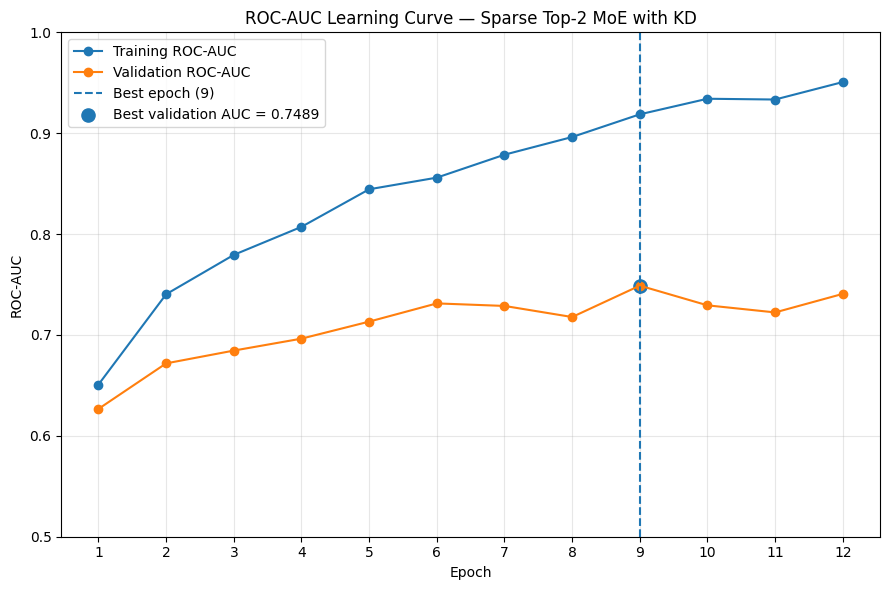

Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/figures/kd_roc_auc_learning_curve.png


In [44]:
import matplotlib.pyplot as plt

epochs = (
    history_dataframe[
        "epoch"
    ].to_numpy(
        dtype=np.int64
    )
)


plt.figure(
    figsize=(9, 6)
)

plt.plot(
    epochs,
    history_dataframe[
        "train_roc_auc"
    ],
    marker="o",
    label="Training ROC-AUC",
)

plt.plot(
    epochs,
    history_dataframe[
        "val_roc_auc"
    ],
    marker="o",
    label="Validation ROC-AUC",
)

plt.axvline(
    BEST_KD_EPOCH,
    linestyle="--",
    label=(
        f"Best epoch "
        f"({BEST_KD_EPOCH})"
    ),
)

plt.scatter(
    [BEST_KD_EPOCH],
    [BEST_KD_VAL_AUC],
    s=90,
    label=(
        f"Best validation AUC "
        f"= {BEST_KD_VAL_AUC:.4f}"
    ),
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "ROC-AUC"
)

plt.title(
    "ROC-AUC Learning Curve — Sparse Top-2 MoE with KD"
)

plt.xticks(
    epochs
)

plt.ylim(
    0.5,
    1.0,
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

auc_curve_path = (
    KD_FIGURE_DIR
    / "kd_roc_auc_learning_curve.png"
)

plt.savefig(
    auc_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    auc_curve_path,
)

## **Average Precision learning curve**

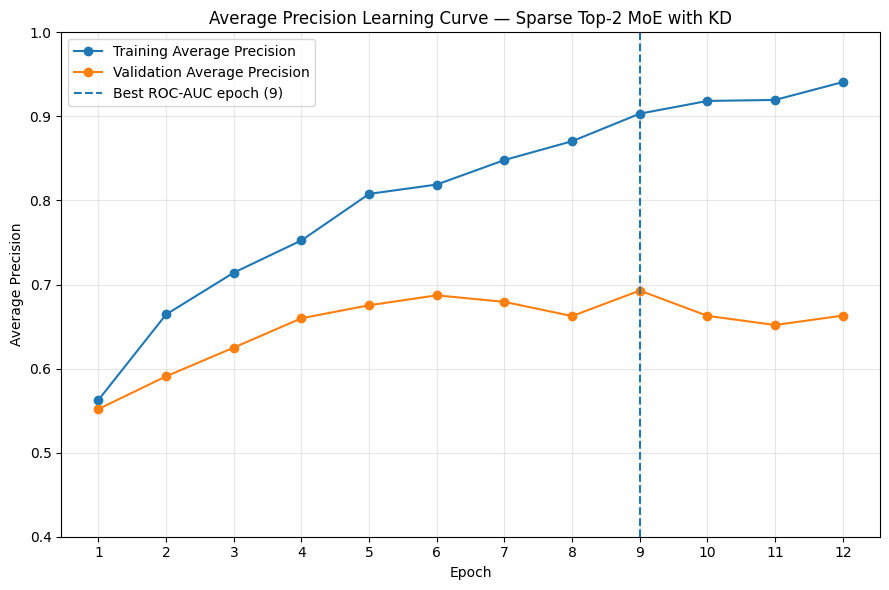

Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/figures/kd_average_precision_learning_curve.png


In [45]:
plt.figure(
    figsize=(9, 6)
)

plt.plot(
    epochs,
    history_dataframe[
        "train_average_precision"
    ],
    marker="o",
    label="Training Average Precision",
)

plt.plot(
    epochs,
    history_dataframe[
        "val_average_precision"
    ],
    marker="o",
    label="Validation Average Precision",
)

plt.axvline(
    BEST_KD_EPOCH,
    linestyle="--",
    label=(
        f"Best ROC-AUC epoch "
        f"({BEST_KD_EPOCH})"
    ),
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Average Precision"
)

plt.title(
    "Average Precision Learning Curve — Sparse Top-2 MoE with KD"
)

plt.xticks(
    epochs
)

plt.ylim(
    0.4,
    1.0,
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

average_precision_curve_path = (
    KD_FIGURE_DIR
    / "kd_average_precision_learning_curve.png"
)

plt.savefig(
    average_precision_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    average_precision_curve_path,
)

## **Total KD loss curve**

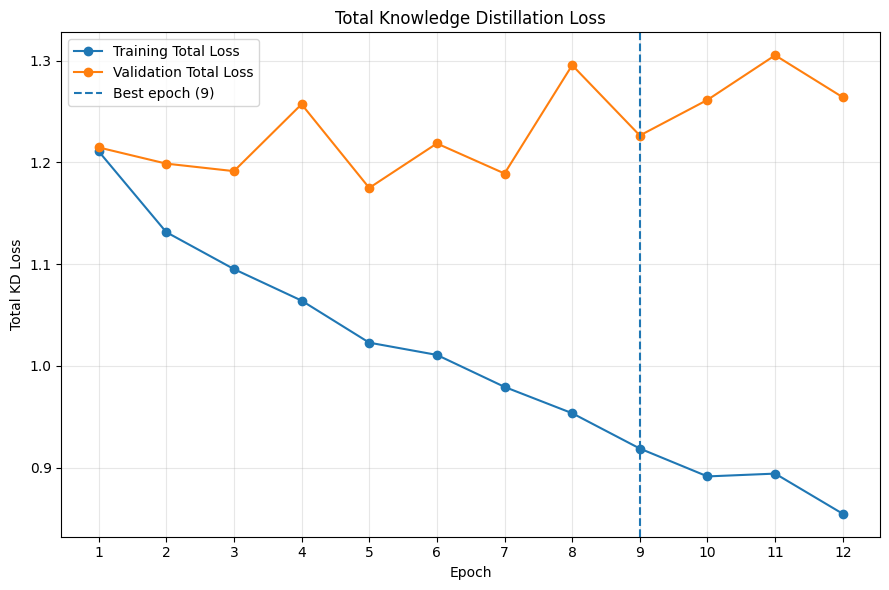

Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/figures/kd_total_loss_curve.png


In [46]:
plt.figure(
    figsize=(9, 6)
)

plt.plot(
    epochs,
    history_dataframe[
        "train_total_loss"
    ],
    marker="o",
    label="Training Total Loss",
)

plt.plot(
    epochs,
    history_dataframe[
        "val_total_loss"
    ],
    marker="o",
    label="Validation Total Loss",
)

plt.axvline(
    BEST_KD_EPOCH,
    linestyle="--",
    label=(
        f"Best epoch "
        f"({BEST_KD_EPOCH})"
    ),
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Total KD Loss"
)

plt.title(
    "Total Knowledge Distillation Loss"
)

plt.xticks(
    epochs
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

total_loss_curve_path = (
    KD_FIGURE_DIR
    / "kd_total_loss_curve.png"
)

plt.savefig(
    total_loss_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    total_loss_curve_path,
)

## **Supervised BCE loss curve**

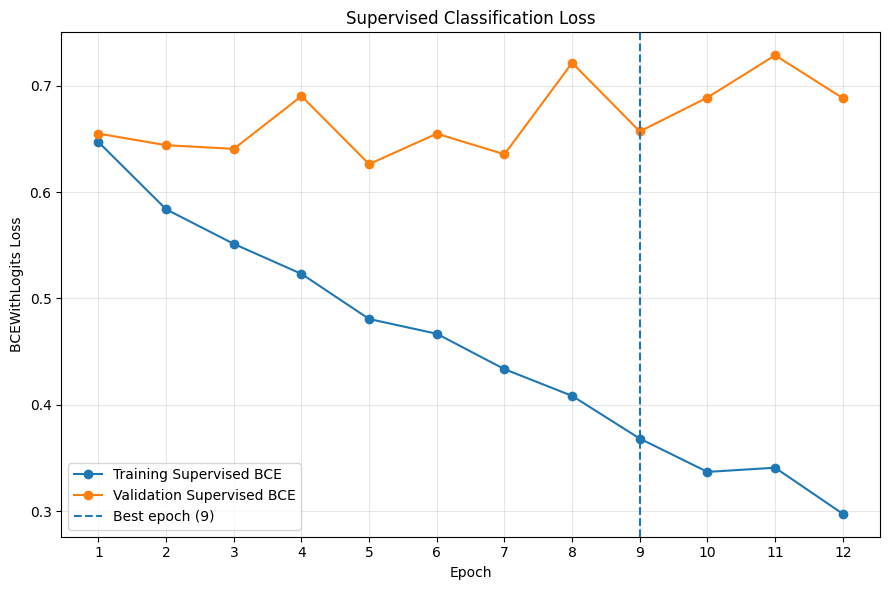

Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/figures/kd_supervised_loss_curve.png


In [47]:
plt.figure(
    figsize=(9, 6)
)

plt.plot(
    epochs,
    history_dataframe[
        "train_supervised_loss"
    ],
    marker="o",
    label="Training Supervised BCE",
)

plt.plot(
    epochs,
    history_dataframe[
        "val_supervised_loss"
    ],
    marker="o",
    label="Validation Supervised BCE",
)

plt.axvline(
    BEST_KD_EPOCH,
    linestyle="--",
    label=(
        f"Best epoch "
        f"({BEST_KD_EPOCH})"
    ),
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "BCEWithLogits Loss"
)

plt.title(
    "Supervised Classification Loss"
)

plt.xticks(
    epochs
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

supervised_loss_curve_path = (
    KD_FIGURE_DIR
    / "kd_supervised_loss_curve.png"
)

plt.savefig(
    supervised_loss_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    supervised_loss_curve_path,
)

## **Logit distillation loss curve**

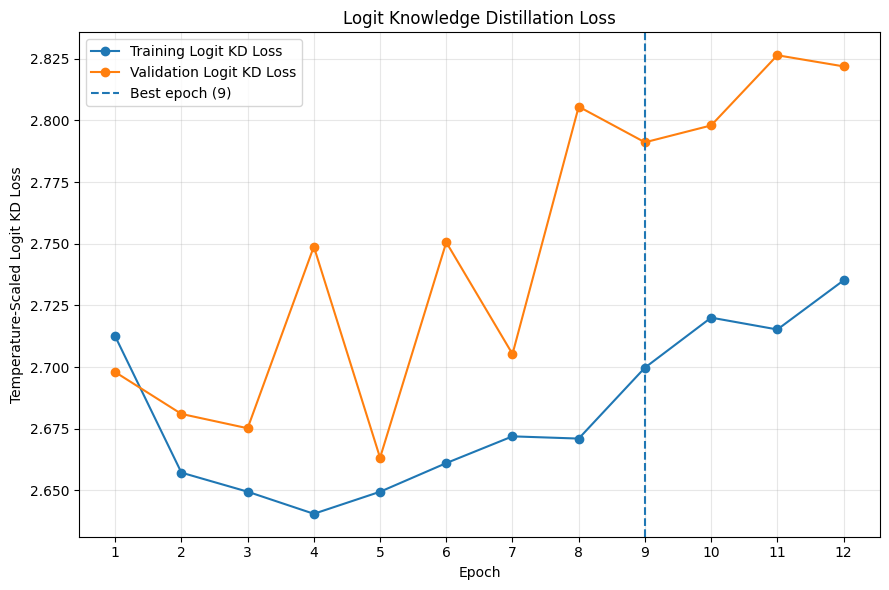

Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/figures/kd_logit_distillation_loss_curve.png


In [48]:
plt.figure(
    figsize=(9, 6)
)

plt.plot(
    epochs,
    history_dataframe[
        "train_logit_kd_loss"
    ],
    marker="o",
    label="Training Logit KD Loss",
)

plt.plot(
    epochs,
    history_dataframe[
        "val_logit_kd_loss"
    ],
    marker="o",
    label="Validation Logit KD Loss",
)

plt.axvline(
    BEST_KD_EPOCH,
    linestyle="--",
    label=(
        f"Best epoch "
        f"({BEST_KD_EPOCH})"
    ),
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Temperature-Scaled Logit KD Loss"
)

plt.title(
    "Logit Knowledge Distillation Loss"
)

plt.xticks(
    epochs
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

logit_kd_curve_path = (
    KD_FIGURE_DIR
    / "kd_logit_distillation_loss_curve.png"
)

plt.savefig(
    logit_kd_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    logit_kd_curve_path,
)

## **Feature distillation loss curve**

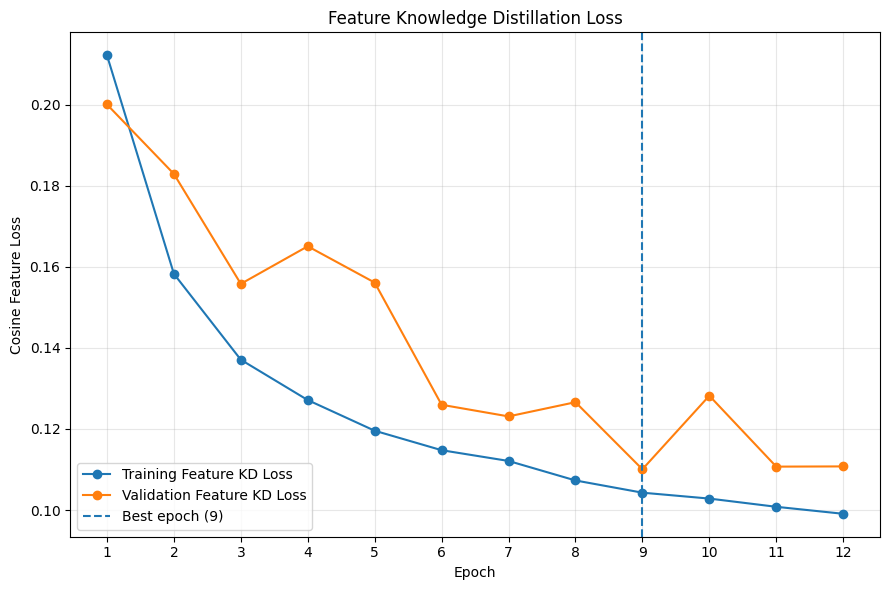

Best-epoch validation feature loss: 0.1101
Best-epoch mean cosine similarity: 0.8899
Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/figures/kd_feature_distillation_loss_curve.png


In [49]:
plt.figure(
    figsize=(9, 6)
)

plt.plot(
    epochs,
    history_dataframe[
        "train_feature_kd_loss"
    ],
    marker="o",
    label="Training Feature KD Loss",
)

plt.plot(
    epochs,
    history_dataframe[
        "val_feature_kd_loss"
    ],
    marker="o",
    label="Validation Feature KD Loss",
)

plt.axvline(
    BEST_KD_EPOCH,
    linestyle="--",
    label=(
        f"Best epoch "
        f"({BEST_KD_EPOCH})"
    ),
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Cosine Feature Loss"
)

plt.title(
    "Feature Knowledge Distillation Loss"
)

plt.xticks(
    epochs
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

feature_kd_curve_path = (
    KD_FIGURE_DIR
    / "kd_feature_distillation_loss_curve.png"
)

plt.savefig(
    feature_kd_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


best_feature_loss = float(
    best_history_row[
        "val_feature_kd_loss"
    ]
)

best_feature_cosine_similarity = (
    1.0
    - best_feature_loss
)


print(
    "Best-epoch validation feature loss:",
    f"{best_feature_loss:.4f}",
)

print(
    "Best-epoch mean cosine similarity:",
    f"{best_feature_cosine_similarity:.4f}",
)

print(
    "Saved:",
    feature_kd_curve_path,
)

## **Generalization gap curve**

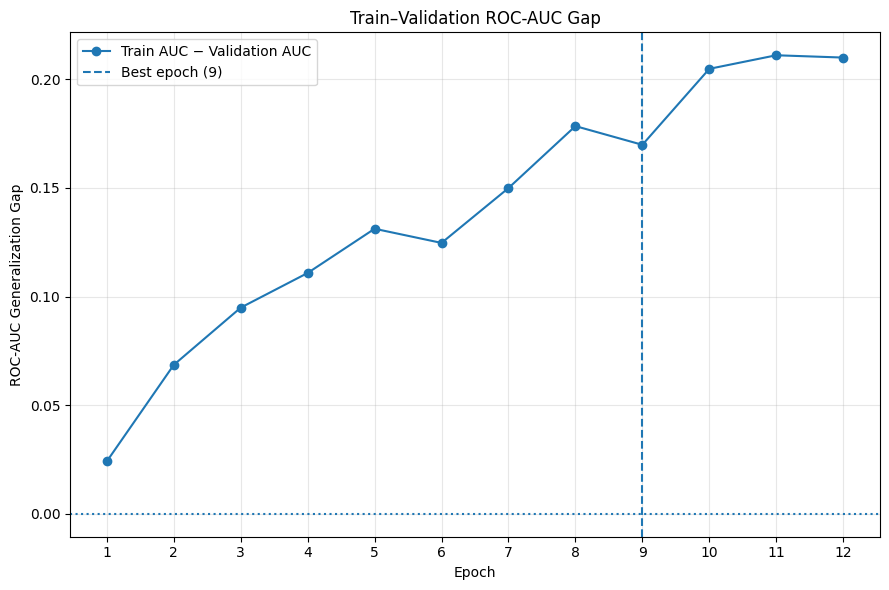

AUC gap at best epoch: 0.1698
AUC gap at last epoch: 0.2100
Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/figures/kd_auc_generalization_gap.png


In [53]:
plt.figure(
    figsize=(9, 6)
)

plt.plot(
    epochs,
    history_dataframe[
        "auc_generalization_gap"
    ],
    marker="o",
    label="Train AUC − Validation AUC",
)

plt.axvline(
    BEST_KD_EPOCH,
    linestyle="--",
    label=(
        f"Best epoch "
        f"({BEST_KD_EPOCH})"
    ),
)

plt.axhline(
    0.0,
    linestyle=":",
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "ROC-AUC Generalization Gap"
)

plt.title(
    "Train–Validation ROC-AUC Gap"
)

plt.xticks(
    epochs
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

generalization_gap_path = (
    KD_FIGURE_DIR
    / "kd_auc_generalization_gap.png"
)

plt.savefig(
    generalization_gap_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


best_auc_gap = float(
    best_history_row[
        "auc_generalization_gap"
    ]
)

last_auc_gap = float(
    history_dataframe.iloc[-1][
        "auc_generalization_gap"
    ]
)


print(
    "AUC gap at best epoch:",
    f"{best_auc_gap:.4f}",
)

print(
    "AUC gap at last epoch:",
    f"{last_auc_gap:.4f}",
)

print(
    "Saved:",
    generalization_gap_path,
)

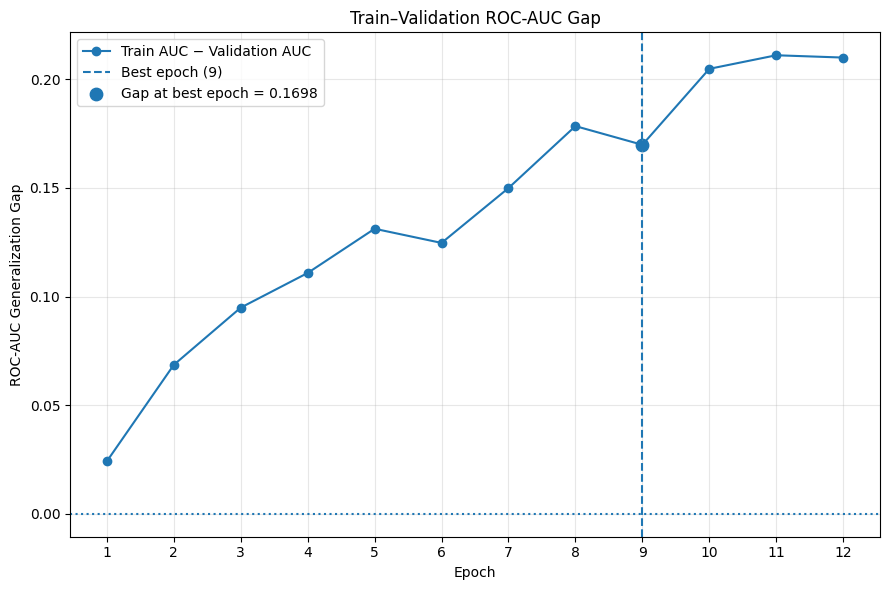

AUC gap at best epoch: 0.1698
AUC gap at last epoch: 0.2100
Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/figures/kd_auc_generalization_gap.png


In [54]:
if (
    "auc_generalization_gap"
    not in history_dataframe.columns
):
    history_dataframe[
        "auc_generalization_gap"
    ] = (
        history_dataframe[
            "train_roc_auc"
        ]
        -
        history_dataframe[
            "val_roc_auc"
        ]
    )


# Retrieve the best row from the latest DataFrame.
best_history_index = (
    history_dataframe[
        "val_roc_auc"
    ].idxmax()
)

best_history_row = (
    history_dataframe.loc[
        best_history_index
    ].copy()
)


plt.figure(
    figsize=(9, 6)
)

plt.plot(
    epochs,
    history_dataframe[
        "auc_generalization_gap"
    ],
    marker="o",
    label="Train AUC − Validation AUC",
)

plt.axvline(
    BEST_KD_EPOCH,
    linestyle="--",
    label=(
        f"Best epoch "
        f"({BEST_KD_EPOCH})"
    ),
)

plt.axhline(
    0.0,
    linestyle=":",
)

plt.scatter(
    [BEST_KD_EPOCH],
    [
        best_history_row[
            "auc_generalization_gap"
        ]
    ],
    s=80,
    label=(
        "Gap at best epoch "
        f"= "
        f"{best_history_row['auc_generalization_gap']:.4f}"
    ),
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "ROC-AUC Generalization Gap"
)

plt.title(
    "Train–Validation ROC-AUC Gap"
)

plt.xticks(
    epochs
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()


generalization_gap_path = (
    KD_FIGURE_DIR
    / "kd_auc_generalization_gap.png"
)

plt.savefig(
    generalization_gap_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


best_auc_gap = float(
    best_history_row[
        "auc_generalization_gap"
    ]
)

last_auc_gap = float(
    history_dataframe.iloc[-1][
        "auc_generalization_gap"
    ]
)


print(
    "AUC gap at best epoch:",
    f"{best_auc_gap:.4f}",
)

print(
    "AUC gap at last epoch:",
    f"{last_auc_gap:.4f}",
)

print(
    "Saved:",
    generalization_gap_path,
)

## **Router entropy curve**

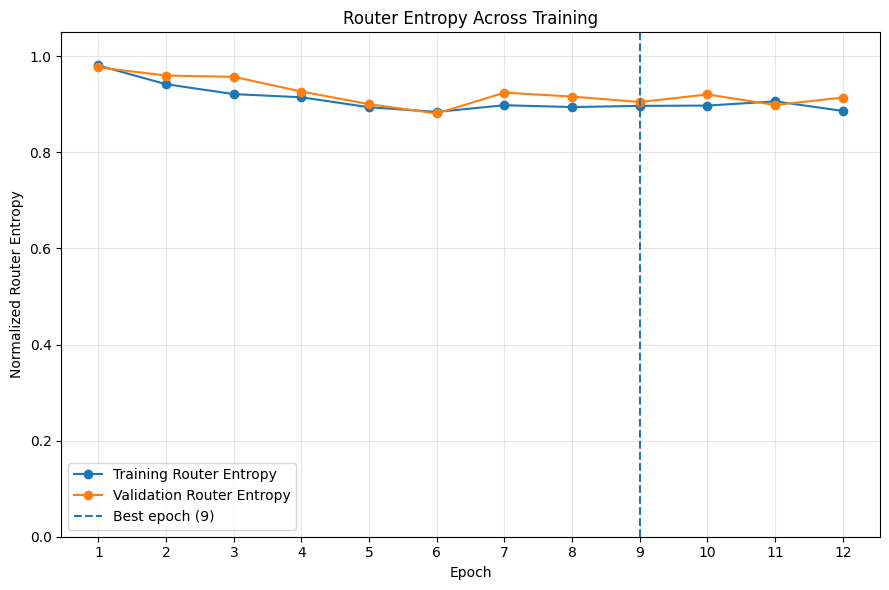

Best-epoch validation router entropy: 0.9048
Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/figures/kd_router_entropy_curve.png


In [55]:
plt.figure(
    figsize=(9, 6)
)

plt.plot(
    epochs,
    history_dataframe[
        "train_router_entropy"
    ],
    marker="o",
    label="Training Router Entropy",
)

plt.plot(
    epochs,
    history_dataframe[
        "val_router_entropy"
    ],
    marker="o",
    label="Validation Router Entropy",
)

plt.axvline(
    BEST_KD_EPOCH,
    linestyle="--",
    label=(
        f"Best epoch "
        f"({BEST_KD_EPOCH})"
    ),
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Normalized Router Entropy"
)

plt.title(
    "Router Entropy Across Training"
)

plt.xticks(
    epochs
)

plt.ylim(
    0.0,
    1.05,
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

router_entropy_path = (
    KD_FIGURE_DIR
    / "kd_router_entropy_curve.png"
)

plt.savefig(
    router_entropy_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Best-epoch validation router entropy:",
    f"{best_history_row['val_router_entropy']:.4f}",
)

print(
    "Saved:",
    router_entropy_path,
)

## **Validation balance loss**

Minimum batchwise minus epoch balance: 0.0016371972


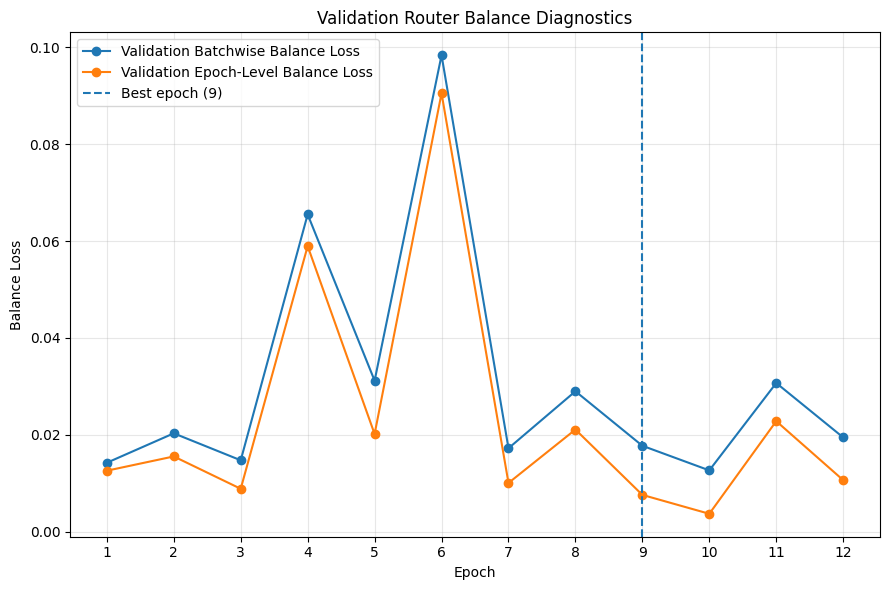

Best-epoch epoch-level balance: 0.007640
Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/figures/kd_validation_router_balance_curve.png


In [56]:
balance_difference = (
    history_dataframe[
        "val_batchwise_balance_loss"
    ]
    -
    history_dataframe[
        "val_epoch_balance_loss"
    ]
)


print(
    "Minimum batchwise minus epoch balance:",
    f"{balance_difference.min():.10f}",
)


assert np.all(
    balance_difference.to_numpy()
    >= -1e-7
)


plt.figure(
    figsize=(9, 6)
)

plt.plot(
    epochs,
    history_dataframe[
        "val_batchwise_balance_loss"
    ],
    marker="o",
    label="Validation Batchwise Balance Loss",
)

plt.plot(
    epochs,
    history_dataframe[
        "val_epoch_balance_loss"
    ],
    marker="o",
    label="Validation Epoch-Level Balance Loss",
)

plt.axvline(
    BEST_KD_EPOCH,
    linestyle="--",
    label=(
        f"Best epoch "
        f"({BEST_KD_EPOCH})"
    ),
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Balance Loss"
)

plt.title(
    "Validation Router Balance Diagnostics"
)

plt.xticks(
    epochs
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

router_balance_path = (
    KD_FIGURE_DIR
    / "kd_validation_router_balance_curve.png"
)

plt.savefig(
    router_balance_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Best-epoch epoch-level balance:",
    f"{best_history_row['val_epoch_balance_loss']:.6f}",
)

print(
    "Saved:",
    router_balance_path,
)

## **Validation hard expert usage**

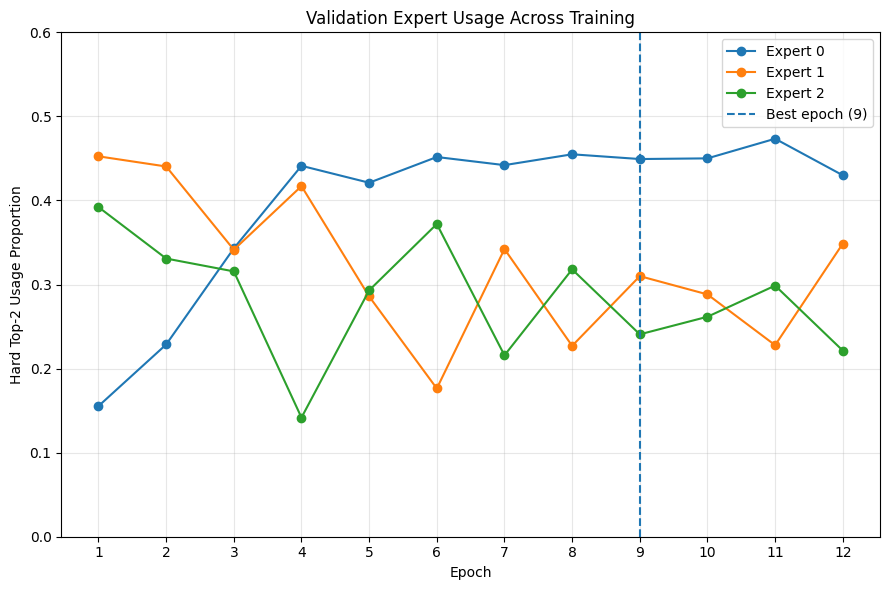

Best-epoch validation expert usage: [0.4493, 0.31, 0.2407]
Total usage: 0.9999999999999999
Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/figures/kd_validation_expert_usage_curve.png


In [57]:
val_expert_usage_columns = [
    (
        f"val_expert_{expert_index}"
        f"_hard_usage"
    )
    for expert_index in range(
        kd_student.num_experts
    )
]


missing_usage_columns = [
    column
    for column in val_expert_usage_columns
    if column not in history_dataframe.columns
]


if missing_usage_columns:
    raise KeyError(
        "Missing validation expert usage "
        f"columns: {missing_usage_columns}"
    )


val_usage_sum = (
    history_dataframe[
        val_expert_usage_columns
    ].sum(axis=1)
)


assert np.allclose(
    val_usage_sum.to_numpy(),
    1.0,
    atol=1e-6,
)


plt.figure(
    figsize=(9, 6)
)

for expert_index in range(
    kd_student.num_experts
):
    plt.plot(
        epochs,
        history_dataframe[
            (
                f"val_expert_{expert_index}"
                f"_hard_usage"
            )
        ],
        marker="o",
        label=(
            f"Expert {expert_index}"
        ),
    )


plt.axvline(
    BEST_KD_EPOCH,
    linestyle="--",
    label=(
        f"Best epoch "
        f"({BEST_KD_EPOCH})"
    ),
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Hard Top-2 Usage Proportion"
)

plt.title(
    "Validation Expert Usage Across Training"
)

plt.xticks(
    epochs
)

plt.ylim(
    0.0,
    0.6,
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

expert_usage_path = (
    KD_FIGURE_DIR
    / "kd_validation_expert_usage_curve.png"
)

plt.savefig(
    expert_usage_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


best_validation_usage = [
    float(
        best_history_row[
            (
                f"val_expert_{expert_index}"
                f"_hard_usage"
            )
        ]
    )
    for expert_index in range(
        kd_student.num_experts
    )
]


print(
    "Best-epoch validation expert usage:",
    [
        round(value, 4)
        for value
        in best_validation_usage
    ],
)

print(
    "Total usage:",
    sum(
        best_validation_usage
    ),
)

print(
    "Saved:",
    expert_usage_path,
)

## **Learning rate schedule**

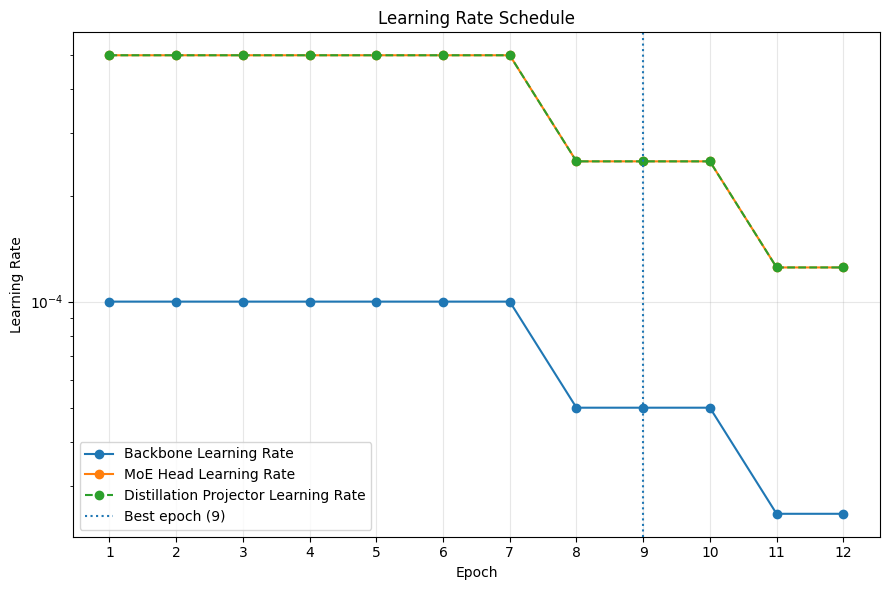

Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/figures/kd_learning_rate_schedule.png


In [58]:
plt.figure(
    figsize=(9, 6)
)

plt.plot(
    epochs,
    history_dataframe[
        "backbone_lr"
    ],
    marker="o",
    label="Backbone Learning Rate",
)

plt.plot(
    epochs,
    history_dataframe[
        "moe_head_lr"
    ],
    marker="o",
    label="MoE Head Learning Rate",
)

plt.plot(
    epochs,
    history_dataframe[
        "projector_lr"
    ],
    marker="o",
    linestyle="--",
    label="Distillation Projector Learning Rate",
)

plt.axvline(
    BEST_KD_EPOCH,
    linestyle=":",
    label=(
        f"Best epoch "
        f"({BEST_KD_EPOCH})"
    ),
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Learning Rate"
)

plt.title(
    "Learning Rate Schedule"
)

plt.xticks(
    epochs
)

plt.yscale(
    "log"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

learning_rate_path = (
    KD_FIGURE_DIR
    / "kd_learning_rate_schedule.png"
)

plt.savefig(
    learning_rate_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    learning_rate_path,
)

## **Best Epoch Summary**

In [59]:
first_history_row = (
    history_dataframe.iloc[0]
)

last_history_row = (
    history_dataframe.iloc[-1]
)


feature_loss_reduction = (
    float(
        first_history_row[
            "val_feature_kd_loss"
        ]
    )
    -
    float(
        best_history_row[
            "val_feature_kd_loss"
        ]
    )
)

feature_loss_reduction_percentage = (
    feature_loss_reduction
    /
    float(
        first_history_row[
            "val_feature_kd_loss"
        ]
    )
    * 100.0
)


best_epoch_summary = {
    "best_epoch": (
        BEST_KD_EPOCH
    ),

    "train_roc_auc": float(
        best_history_row[
            "train_roc_auc"
        ]
    ),

    "validation_roc_auc": float(
        best_history_row[
            "val_roc_auc"
        ]
    ),

    "auc_generalization_gap": float(
        best_history_row[
            "auc_generalization_gap"
        ]
    ),

    "validation_average_precision": float(
        best_history_row[
            "val_average_precision"
        ]
    ),

    "validation_total_loss": float(
        best_history_row[
            "val_total_loss"
        ]
    ),

    "validation_supervised_loss": float(
        best_history_row[
            "val_supervised_loss"
        ]
    ),

    "validation_logit_kd_loss": float(
        best_history_row[
            "val_logit_kd_loss"
        ]
    ),

    "validation_feature_kd_loss": float(
        best_history_row[
            "val_feature_kd_loss"
        ]
    ),

    "validation_feature_cosine_similarity": float(
        best_history_row[
            "val_feature_cosine_similarity"
        ]
    ),

    "validation_sensitivity_at_0_5": float(
        best_history_row[
            "val_sensitivity"
        ]
    ),

    "validation_specificity_at_0_5": float(
        best_history_row[
            "val_specificity"
        ]
    ),

    "validation_f1_at_0_5": float(
        best_history_row[
            "val_f1_score"
        ]
    ),

    "validation_router_entropy": float(
        best_history_row[
            "val_router_entropy"
        ]
    ),

    "validation_batchwise_balance_loss": float(
        best_history_row[
            "val_batchwise_balance_loss"
        ]
    ),

    "validation_epoch_balance_loss": float(
        best_history_row[
            "val_epoch_balance_loss"
        ]
    ),

    "expert_0_hard_usage": float(
        best_history_row[
            "val_expert_0_hard_usage"
        ]
    ),

    "expert_1_hard_usage": float(
        best_history_row[
            "val_expert_1_hard_usage"
        ]
    ),

    "expert_2_hard_usage": float(
        best_history_row[
            "val_expert_2_hard_usage"
        ]
    ),

    "feature_loss_reduction_from_epoch_1": float(
        feature_loss_reduction
    ),

    "feature_loss_reduction_percentage": float(
        feature_loss_reduction_percentage
    ),

    "last_epoch_auc_gap": float(
        last_history_row[
            "auc_generalization_gap"
        ]
    ),

    "elapsed_minutes_at_best_epoch": float(
        best_history_row[
            "elapsed_minutes"
        ]
    ),
}


best_epoch_summary_dataframe = (
    pd.DataFrame(
        [
            best_epoch_summary
        ]
    )
)


display(
    best_epoch_summary_dataframe.T
    .rename(
        columns={
            0: "Value"
        }
    )
)


derived_history_path = (
    KD_ANALYSIS_DIR
    / "kd_training_history_with_derived_metrics.csv"
)

best_summary_csv_path = (
    KD_ANALYSIS_DIR
    / "kd_best_epoch_summary.csv"
)

best_summary_json_path = (
    KD_ANALYSIS_DIR
    / "kd_best_epoch_summary.json"
)


history_dataframe.to_csv(
    derived_history_path,
    index=False,
)

best_epoch_summary_dataframe.to_csv(
    best_summary_csv_path,
    index=False,
)

with open(
    best_summary_json_path,
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        best_epoch_summary,
        json_file,
        indent=4,
    )


print(
    "Feature loss reduction:",
    f"{feature_loss_reduction:.4f}",
)

print(
    "Feature loss reduction percentage:",
    f"{feature_loss_reduction_percentage:.2f}%",
)

print()

print(
    "Saved derived history:",
    derived_history_path,
)

print(
    "Saved best-epoch CSV:",
    best_summary_csv_path,
)

print(
    "Saved best-epoch JSON:",
    best_summary_json_path,
)

print(
    "Knowledge Distillation learning-curve "
    "analysis completed."
)

,Value
best_epoch,9.000000
train_roc_auc,0.918723
validation_roc_auc,0.748899
auc_generalization_gap,0.169824
validation_average_precision,0.692797
validation_total_loss,1.226455
validation_supervised_loss,0.657051
validation_logit_kd_loss,2.791100
validation_feature_kd_loss,0.110058
validation_feature_cosine_similarity,0.889942


Feature loss reduction: 0.0900
Feature loss reduction percentage: 44.99%

Saved derived history: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/analysis/kd_training_history_with_derived_metrics.csv
Saved best-epoch CSV: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/analysis/kd_best_epoch_summary.csv
Saved best-epoch JSON: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/analysis/kd_best_epoch_summary.json
Knowledge Distillation learning-curve analysis completed.


# **Final Evaluation of Sparse Top-2 MoE with Knowledge Distillation**

## **Setting up a deployable model**

In [60]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)


KD_FINAL_EVALUATION_DIR = (
    KD_OUTPUT_DIR
    / "final_evaluation"
)

KD_FINAL_EVALUATION_FIGURE_DIR = (
    KD_FINAL_EVALUATION_DIR
    / "figures"
)

KD_FINAL_EVALUATION_TABLE_DIR = (
    KD_FINAL_EVALUATION_DIR
    / "tables"
)

KD_FINAL_EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

KD_FINAL_EVALUATION_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

KD_FINAL_EVALUATION_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


assert BEST_KD_PATH.exists(), (
    f"Best KD checkpoint was not found: "
    f"{BEST_KD_PATH}"
)


best_kd_checkpoint = torch.load(
    BEST_KD_PATH,
    map_location=DEVICE,
    weights_only=False,
)


# Muat kembali model lengkap untuk verifikasi.
kd_student.load_state_dict(
    best_kd_checkpoint[
        "model_state_dict"
    ],
    strict=True,
)

kd_student.eval()


# Bangun model deployment tanpa distillation projector.
kd_deployable_model = (
    MobileNetV3SmallSparseMoE(
        pretrained=False,
        num_experts=3,
        top_k=2,
        expert_hidden_dim=128,
        router_hidden_dim=128,
        expert_dropout=0.2,
        router_dropout=0.1,
    )
).to(
    DEVICE
)


deployable_state_dict = {
    parameter_name: parameter_value
    for (
        parameter_name,
        parameter_value,
    )
    in best_kd_checkpoint[
        "model_state_dict"
    ].items()
    if not parameter_name.startswith(
        "distill_projector."
    )
}


kd_deployable_model.load_state_dict(
    deployable_state_dict,
    strict=True,
)

kd_deployable_model.eval()


kd_deployable_parameter_count = sum(
    parameter.numel()
    for parameter
    in kd_deployable_model.parameters()
)

kd_training_parameter_count = sum(
    parameter.numel()
    for parameter
    in kd_student.parameters()
)


print(
    "Best checkpoint epoch:",
    best_kd_checkpoint["epoch"],
)

print(
    "Stored validation ROC-AUC:",
    f"{best_kd_checkpoint['best_val_auc']:.6f}",
)

print(
    "Training parameters:",
    f"{kd_training_parameter_count:,}",
)

print(
    "Deployable parameters:",
    f"{kd_deployable_parameter_count:,}",
)


assert (
    kd_training_parameter_count
    == 1_519_654
)

assert (
    kd_deployable_parameter_count
    == 1_223_206
)

Best checkpoint epoch: 9
Stored validation ROC-AUC: 0.748899
Training parameters: 1,519,654
Deployable parameters: 1,223,206


**Verify that the projector does not affect the classification logits**

In [61]:
verification_batch = next(
    iter(kd_val_loader)
)

verification_images = (
    verification_batch["images"]
    .to(
        DEVICE,
        non_blocking=True,
    )
)


with torch.inference_mode():
    with torch.autocast(
        device_type=DEVICE.type,
        dtype=torch.float16,
        enabled=USE_AMP,
    ):
        full_kd_output = kd_student(
            verification_images,
            return_features=False,
        )

        deployable_output = (
            kd_deployable_model(
                verification_images,
                return_features=False,
            )
        )


full_kd_logits = (
    full_kd_output["logits"]
    .detach()
    .float()
)

deployable_logits = (
    deployable_output["logits"]
    .detach()
    .float()
)


maximum_logit_difference = float(
    (
        full_kd_logits
        - deployable_logits
    )
    .abs()
    .max()
    .cpu()
)


print(
    "Maximum logit difference:",
    f"{maximum_logit_difference:.10f}",
)


assert (
    maximum_logit_difference
    < 1e-6
), (
    "Deployable model logits differ "
    "from full KD model logits."
)


evaluation_model = (
    kd_deployable_model
)


del verification_batch
del verification_images
del full_kd_output
del deployable_output
del full_kd_logits
del deployable_logits

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


print(
    "Deployable KD model verified."
)

Maximum logit difference: 0.0000000000
Deployable KD model verified.


## **Collecting forecasts and routing**

In [62]:
def extract_string_metadata(
    batch,
    key,
    batch_size,
    default_value="",
):
    if key not in batch:
        return [
            default_value
            for _ in range(
                batch_size
            )
        ]

    values = batch[key]

    if torch.is_tensor(
        values
    ):
        values = (
            values
            .detach()
            .cpu()
            .tolist()
        )

    return [
        str(value)
        for value in values
    ]


@torch.inference_mode()
def collect_kd_validation_outputs(
    model,
    data_loader,
    device,
):
    model.eval()

    records = []

    progress_bar = tqdm(
        data_loader,
        desc="Collecting final KD predictions",
        leave=False,
    )


    for batch in progress_bar:
        images = (
            batch["images"]
            .to(
                device,
                non_blocking=True,
            )
        )

        labels = (
            batch["labels"]
            .detach()
            .cpu()
            .numpy()
            .astype(np.int64)
            .reshape(-1)
        )

        teacher_logits = (
            batch["teacher_logit"]
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
            .reshape(-1)
        )


        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            output = model(
                images,
                return_features=False,
            )


        student_logits = (
            output["logits"]
            .detach()
            .float()
            .cpu()
            .numpy()
            .reshape(-1)
        )

        student_probabilities = (
            torch.sigmoid(
                output["logits"]
                .detach()
                .float()
            )
            .cpu()
            .numpy()
            .reshape(-1)
        )

        teacher_probabilities = (
            1.0
            / (
                1.0
                + np.exp(
                    -teacher_logits
                )
            )
        )


        expert_logits = (
            output[
                "expert_logits"
            ]
            .detach()
            .float()
            .cpu()
            .numpy()
        )

        expert_logits = (
            expert_logits.reshape(
                len(labels),
                model.num_experts,
            )
        )


        router_probabilities = (
            output[
                "router_probabilities"
            ]
            .detach()
            .float()
            .cpu()
            .numpy()
        )

        sparse_gates = (
            output[
                "sparse_gates"
            ]
            .detach()
            .float()
            .cpu()
            .numpy()
        )

        topk_indices = (
            output[
                "topk_indices"
            ]
            .detach()
            .cpu()
            .numpy()
            .astype(np.int64)
        )


        normalized_entropy = (
            -np.sum(
                router_probabilities
                * np.log(
                    router_probabilities
                    + 1e-12
                ),
                axis=1,
            )
            / np.log(
                model.num_experts
            )
        )


        image_paths = (
            extract_string_metadata(
                batch=batch,
                key="image_path",
                batch_size=len(labels),
            )
        )

        patient_ids = (
            extract_string_metadata(
                batch=batch,
                key="patient_id",
                batch_size=len(labels),
            )
        )


        for sample_index in range(
            len(labels)
        ):
            top1_expert = int(
                topk_indices[
                    sample_index,
                    0,
                ]
            )

            top2_expert = int(
                topk_indices[
                    sample_index,
                    1,
                ]
            )


            record = {
                "image_path": (
                    image_paths[
                        sample_index
                    ]
                ),

                "patient_id": (
                    patient_ids[
                        sample_index
                    ]
                ),

                "label": int(
                    labels[
                        sample_index
                    ]
                ),

                "student_logit": float(
                    student_logits[
                        sample_index
                    ]
                ),

                "probability": float(
                    student_probabilities[
                        sample_index
                    ]
                ),

                "teacher_logit": float(
                    teacher_logits[
                        sample_index
                    ]
                ),

                "teacher_probability": float(
                    teacher_probabilities[
                        sample_index
                    ]
                ),

                "router_entropy": float(
                    normalized_entropy[
                        sample_index
                    ]
                ),

                "top1_expert": (
                    top1_expert
                ),

                "top2_expert": (
                    top2_expert
                ),

                "top1_gate": float(
                    sparse_gates[
                        sample_index,
                        top1_expert,
                    ]
                ),

                "top2_gate": float(
                    sparse_gates[
                        sample_index,
                        top2_expert,
                    ]
                ),
            }


            for expert_index in range(
                model.num_experts
            ):
                record[
                    f"expert_{expert_index}_logit"
                ] = float(
                    expert_logits[
                        sample_index,
                        expert_index,
                    ]
                )

                record[
                    f"expert_{expert_index}_router_probability"
                ] = float(
                    router_probabilities[
                        sample_index,
                        expert_index,
                    ]
                )

                record[
                    f"expert_{expert_index}_sparse_gate"
                ] = float(
                    sparse_gates[
                        sample_index,
                        expert_index,
                    ]
                )


            records.append(
                record
            )


    prediction_dataframe = (
        pd.DataFrame(
            records
        )
    )


    return prediction_dataframe

In [63]:
kd_prediction_dataframe = (
    collect_kd_validation_outputs(
        model=evaluation_model,
        data_loader=kd_val_loader,
        device=DEVICE,
    )
)


print(
    "Validation predictions:",
    len(kd_prediction_dataframe),
)

display(
    kd_prediction_dataframe.head()
)


assert (
    len(kd_prediction_dataframe)
    == 621
)

assert (
    kd_prediction_dataframe[
        "label"
    ].value_counts().to_dict()
    == {
        0: 334,
        1: 287,
    }
)

assert np.isfinite(
    kd_prediction_dataframe[
        "probability"
    ].to_numpy()
).all()

assert np.isclose(
    kd_prediction_dataframe[
        [
            "top1_gate",
            "top2_gate",
        ]
    ].sum(axis=1),
    1.0,
    atol=1e-5,
).all()


print(
    "KD prediction and routing "
    "collection verified."
)

Validation predictions: 621


,image_path,patient_id,label,student_logit,probability,teacher_logit,teacher_probability,router_entropy,top1_expert,top2_expert,...,top2_gate,expert_0_logit,expert_0_router_probability,expert_0_sparse_gate,expert_1_logit,expert_1_router_probability,expert_1_sparse_gate,expert_2_logit,expert_2_router_probability,expert_2_sparse_gate
0,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_01510,0,-1.723512,0.151419,0.043793,0.510946,0.952957,2,0,...,0.370197,-1.243164,0.284932,0.370197,-0.974121,0.230323,0.000000,-2.005859,0.484745,0.629803
1,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00281,0,0.348625,0.586284,0.418945,0.603231,0.986252,1,0,...,0.460486,-0.359619,0.340971,0.460486,0.953125,0.399489,0.539514,-1.054688,0.259540,0.000000
2,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00008,0,1.517067,0.820106,-0.180908,0.454896,0.980267,1,0,...,0.435635,0.757324,0.325690,0.435635,2.103516,0.421932,0.564365,-0.733398,0.252378,0.000000
3,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00078,1,-0.525816,0.371493,-0.494873,0.378746,0.999425,2,1,...,0.485949,-0.537109,0.320659,0.000000,0.284668,0.330125,0.485949,-1.291992,0.349216,0.514051
4,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_01395,0,-1.729814,0.150611,-2.357422,0.086478,0.968517,2,0,...,0.386879,-0.911621,0.289072,0.386879,1.201172,0.252811,0.000000,-2.246094,0.458117,0.613121


KD prediction and routing collection verified.


## **ROC-AUC, PR-AUC and Youden’s threshold**

In [64]:
kd_labels = (
    kd_prediction_dataframe[
        "label"
    ].to_numpy(
        dtype=np.int64
    )
)

kd_probabilities = (
    kd_prediction_dataframe[
        "probability"
    ].to_numpy(
        dtype=np.float64
    )
)


kd_roc_auc = float(
    roc_auc_score(
        kd_labels,
        kd_probabilities,
    )
)


(
    kd_false_positive_rates,
    kd_true_positive_rates,
    kd_roc_thresholds,
) = roc_curve(
    kd_labels,
    kd_probabilities,
)


(
    kd_precision_curve,
    kd_recall_curve,
    kd_pr_thresholds,
) = precision_recall_curve(
    kd_labels,
    kd_probabilities,
)


kd_pr_auc = float(
    auc(
        kd_recall_curve,
        kd_precision_curve,
    )
)

kd_average_precision = float(
    average_precision_score(
        kd_labels,
        kd_probabilities,
    )
)


kd_youden_values = (
    kd_true_positive_rates
    -
    kd_false_positive_rates
)

kd_youden_index = int(
    np.argmax(
        kd_youden_values
    )
)

KD_YOUDEN_THRESHOLD = float(
    kd_roc_thresholds[
        kd_youden_index
    ]
)

kd_youden_sensitivity = float(
    kd_true_positive_rates[
        kd_youden_index
    ]
)

kd_youden_specificity = float(
    1.0
    -
    kd_false_positive_rates[
        kd_youden_index
    ]
)

kd_youden_j = float(
    kd_youden_values[
        kd_youden_index
    ]
)


print(
    "KD validation ROC-AUC:",
    f"{kd_roc_auc:.4f}",
)

print(
    "KD validation PR-AUC :",
    f"{kd_pr_auc:.4f}",
)

print(
    "KD Average Precision :",
    f"{kd_average_precision:.4f}",
)

print()

print(
    "KD optimal threshold:",
    f"{KD_YOUDEN_THRESHOLD:.4f}",
)

print(
    "Sensitivity:",
    f"{kd_youden_sensitivity:.4f}",
)

print(
    "Specificity:",
    f"{kd_youden_specificity:.4f}",
)

print(
    "Youden's J:",
    f"{kd_youden_j:.4f}",
)


stored_best_auc = float(
    best_kd_checkpoint[
        "best_val_auc"
    ]
)

auc_reproduction_difference = abs(
    kd_roc_auc
    - stored_best_auc
)


print(
    "AUC reproduction difference:",
    f"{auc_reproduction_difference:.8f}",
)


assert (
    auc_reproduction_difference
    < 5e-4
), (
    "Final evaluation ROC-AUC "
    "does not reproduce the "
    "best checkpoint metric."
)

KD validation ROC-AUC: 0.7489
KD validation PR-AUC : 0.6917
KD Average Precision : 0.6928

KD optimal threshold: 0.2530
Sensitivity: 0.8502
Specificity: 0.5329
Youden's J: 0.3831
AUC reproduction difference: 0.00000000


## **Comparing a threshold of 0.5 and the Youden index**

In [65]:
def calculate_threshold_metrics(
    labels,
    probabilities,
    threshold,
    threshold_type,
    roc_auc_value,
    pr_auc_value,
    average_precision_value,
):
    predictions = (
        probabilities
        >= threshold
    ).astype(
        np.int64
    )


    (
        true_negative,
        false_positive,
        false_negative,
        true_positive,
    ) = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    ).ravel()


    sensitivity = float(
        recall_score(
            labels,
            predictions,
            pos_label=1,
            zero_division=0,
        )
    )

    specificity = float(
        true_negative
        / (
            true_negative
            + false_positive
        )
    )


    return {
        "threshold_type": (
            threshold_type
        ),

        "threshold": float(
            threshold
        ),

        "roc_auc": float(
            roc_auc_value
        ),

        "pr_auc": float(
            pr_auc_value
        ),

        "average_precision": float(
            average_precision_value
        ),

        "accuracy": float(
            accuracy_score(
                labels,
                predictions,
            )
        ),

        "balanced_accuracy": float(
            balanced_accuracy_score(
                labels,
                predictions,
            )
        ),

        "precision": float(
            precision_score(
                labels,
                predictions,
                pos_label=1,
                zero_division=0,
            )
        ),

        "sensitivity": (
            sensitivity
        ),

        "specificity": (
            specificity
        ),

        "f1": float(
            f1_score(
                labels,
                predictions,
                pos_label=1,
                zero_division=0,
            )
        ),

        "tn": int(
            true_negative
        ),

        "fp": int(
            false_positive
        ),

        "fn": int(
            false_negative
        ),

        "tp": int(
            true_positive
        ),
    }

In [66]:
kd_default_metrics = (
    calculate_threshold_metrics(
        labels=kd_labels,
        probabilities=kd_probabilities,
        threshold=0.5,
        threshold_type="Default 0.5",
        roc_auc_value=kd_roc_auc,
        pr_auc_value=kd_pr_auc,
        average_precision_value=(
            kd_average_precision
        ),
    )
)

kd_youden_metrics = (
    calculate_threshold_metrics(
        labels=kd_labels,
        probabilities=kd_probabilities,
        threshold=(
            KD_YOUDEN_THRESHOLD
        ),
        threshold_type="Youden optimal",
        roc_auc_value=kd_roc_auc,
        pr_auc_value=kd_pr_auc,
        average_precision_value=(
            kd_average_precision
        ),
    )
)


kd_threshold_comparison_dataframe = (
    pd.DataFrame(
        [
            kd_default_metrics,
            kd_youden_metrics,
        ]
    )
)


display(
    kd_threshold_comparison_dataframe
    .round(4)
)

,threshold_type,threshold,roc_auc,pr_auc,average_precision,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,tn,fp,fn,tp
0,Default 0.5,0.500,0.7489,0.6917,0.6928,0.6779,0.6805,0.6347,0.7143,0.6467,0.6721,216,118,82,205
1,Youden optimal,0.253,0.7489,0.6917,0.6928,0.6795,0.6916,0.6100,0.8502,0.5329,0.7103,178,156,43,244


## **Classification report and confusion matrix**

,precision,recall,f1-score,support
Benign,0.8054,0.5329,0.6414,334.0000
Malignant,0.6100,0.8502,0.7103,287.0000
accuracy,0.6795,0.6795,0.6795,0.6795
macro avg,0.7077,0.6916,0.6759,621.0000
weighted avg,0.7151,0.6795,0.6733,621.0000


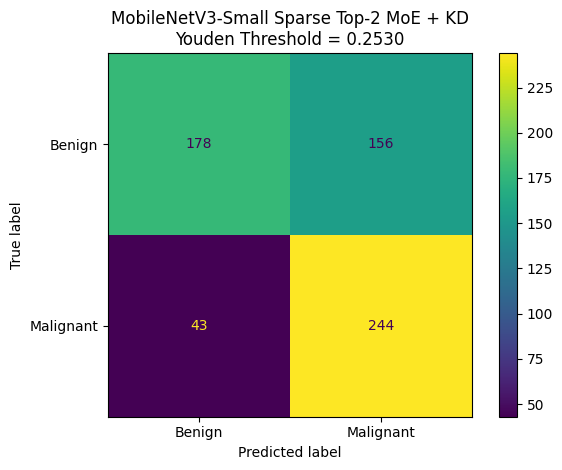

Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/final_evaluation/figures/kd_youden_confusion_matrix.png


In [67]:
kd_youden_predictions = (
    kd_probabilities
    >= KD_YOUDEN_THRESHOLD
).astype(
    np.int64
)


kd_classification_report_dictionary = (
    classification_report(
        kd_labels,
        kd_youden_predictions,
        target_names=[
            "Benign",
            "Malignant",
        ],
        output_dict=True,
        zero_division=0,
    )
)


kd_classification_report_dataframe = (
    pd.DataFrame(
        kd_classification_report_dictionary
    ).transpose()
)


display(
    kd_classification_report_dataframe
    .round(4)
)


kd_confusion_matrix = (
    confusion_matrix(
        kd_labels,
        kd_youden_predictions,
        labels=[0, 1],
    )
)


kd_confusion_matrix_display = (
    ConfusionMatrixDisplay(
        confusion_matrix=(
            kd_confusion_matrix
        ),
        display_labels=[
            "Benign",
            "Malignant",
        ],
    )
)


kd_confusion_matrix_display.plot(
    values_format="d",
)

plt.title(
    "MobileNetV3-Small Sparse Top-2 MoE + KD\n"
    f"Youden Threshold = "
    f"{KD_YOUDEN_THRESHOLD:.4f}"
)

plt.tight_layout()


kd_confusion_matrix_path = (
    KD_FINAL_EVALUATION_FIGURE_DIR
    / "kd_youden_confusion_matrix.png"
)

plt.savefig(
    kd_confusion_matrix_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Saved:",
    kd_confusion_matrix_path,
)

## **ROC and Precision–Recall Curve**

**ROC Curve**

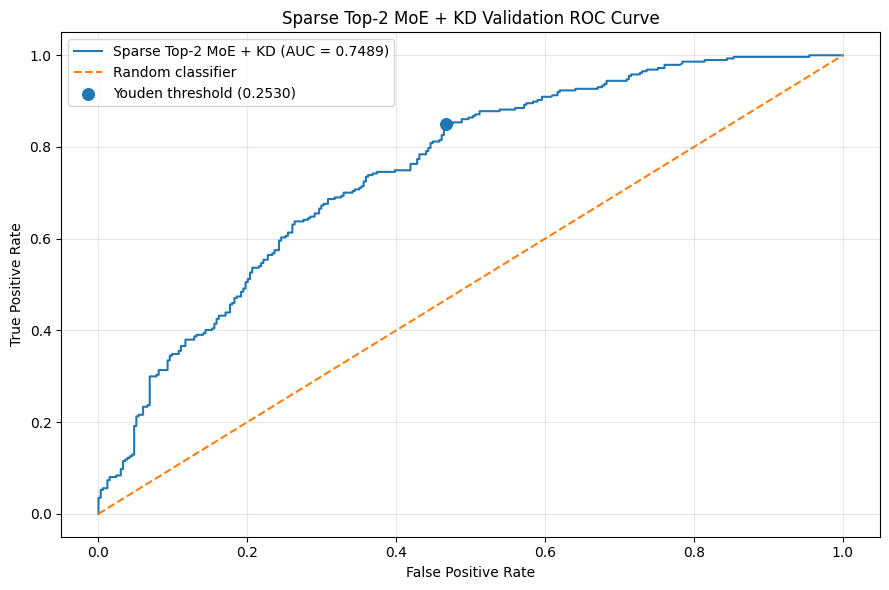

Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/final_evaluation/figures/kd_validation_roc_curve.png


In [68]:
plt.figure(
    figsize=(9, 6)
)

plt.plot(
    kd_false_positive_rates,
    kd_true_positive_rates,
    label=(
        "Sparse Top-2 MoE + KD "
        f"(AUC = {kd_roc_auc:.4f})"
    ),
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier",
)

plt.scatter(
    [
        kd_false_positive_rates[
            kd_youden_index
        ]
    ],
    [
        kd_true_positive_rates[
            kd_youden_index
        ]
    ],
    s=70,
    label=(
        "Youden threshold "
        f"({KD_YOUDEN_THRESHOLD:.4f})"
    ),
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Sparse Top-2 MoE + KD Validation ROC Curve"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()


kd_roc_curve_path = (
    KD_FINAL_EVALUATION_FIGURE_DIR
    / "kd_validation_roc_curve.png"
)

plt.savefig(
    kd_roc_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Saved:",
    kd_roc_curve_path,
)

**Precision-Recall Curve**

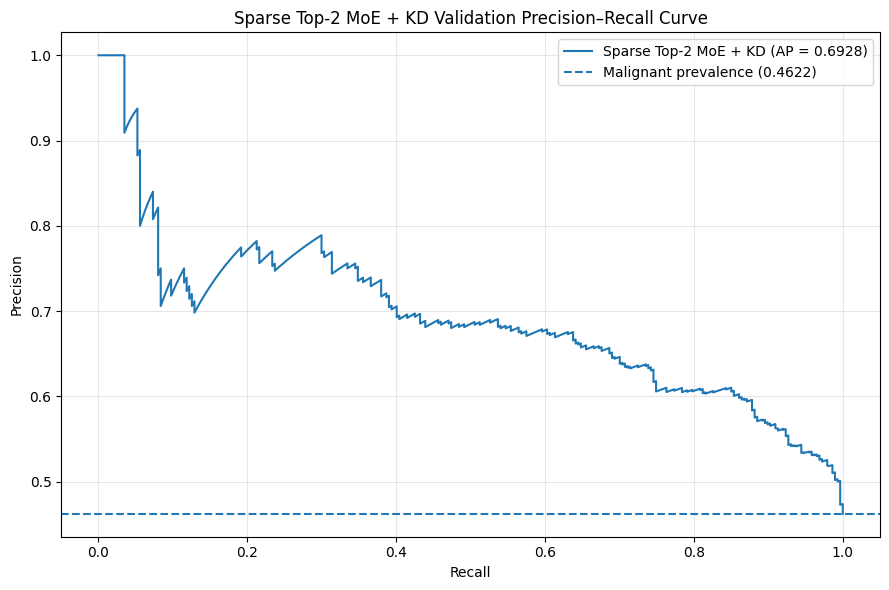

Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/final_evaluation/figures/kd_validation_precision_recall_curve.png


In [69]:
kd_malignant_prevalence = float(
    kd_labels.mean()
)


plt.figure(
    figsize=(9, 6)
)

plt.plot(
    kd_recall_curve,
    kd_precision_curve,
    label=(
        "Sparse Top-2 MoE + KD "
        f"(AP = {kd_average_precision:.4f})"
    ),
)

plt.axhline(
    kd_malignant_prevalence,
    linestyle="--",
    label=(
        "Malignant prevalence "
        f"({kd_malignant_prevalence:.4f})"
    ),
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Sparse Top-2 MoE + KD "
    "Validation Precision–Recall Curve"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()


kd_pr_curve_path = (
    KD_FINAL_EVALUATION_FIGURE_DIR
    / "kd_validation_precision_recall_curve.png"
)

plt.savefig(
    kd_pr_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Saved:",
    kd_pr_curve_path,
)

## **Global routing statistics**

In [70]:
number_of_validation_samples = len(
    kd_prediction_dataframe
)

number_of_experts = (
    evaluation_model.num_experts
)

top_k = (
    evaluation_model.top_k
)


global_routing_records = []


for expert_index in range(
    number_of_experts
):
    expert_selected_mask = (
        (
            kd_prediction_dataframe[
                "top1_expert"
            ]
            == expert_index
        )
        |
        (
            kd_prediction_dataframe[
                "top2_expert"
            ]
            == expert_index
        )
    )

    selection_count = int(
        expert_selected_mask.sum()
    )


    global_routing_records.append(
        {
            "expert": (
                f"Expert {expert_index}"
            ),

            "mean_router_probability": float(
                kd_prediction_dataframe[
                    (
                        f"expert_{expert_index}"
                        f"_router_probability"
                    )
                ].mean()
            ),

            "selection_count": (
                selection_count
            ),

            "hard_top2_usage": float(
                selection_count
                / (
                    number_of_validation_samples
                    * top_k
                )
            ),

            "mean_sparse_gate": float(
                kd_prediction_dataframe[
                    (
                        f"expert_{expert_index}"
                        f"_sparse_gate"
                    )
                ].mean()
            ),

            "mean_expert_logit": float(
                kd_prediction_dataframe[
                    (
                        f"expert_{expert_index}"
                        f"_logit"
                    )
                ].mean()
            ),
        }
    )


kd_global_routing_dataframe = (
    pd.DataFrame(
        global_routing_records
    )
)


kd_mean_router_probabilities = (
    kd_global_routing_dataframe[
        "mean_router_probability"
    ].to_numpy(
        dtype=np.float64
    )
)


kd_epoch_level_balance_loss = float(
    number_of_experts
    * np.sum(
        kd_mean_router_probabilities
        ** 2
    )
    - 1.0
)


kd_mean_router_entropy = float(
    kd_prediction_dataframe[
        "router_entropy"
    ].mean()
)


kd_total_hard_usage = float(
    kd_global_routing_dataframe[
        "hard_top2_usage"
    ].sum()
)


display(
    kd_global_routing_dataframe
    .round(6)
)


print(
    "Mean router entropy:",
    f"{kd_mean_router_entropy:.6f}",
)

print(
    "Epoch-level balance loss:",
    f"{kd_epoch_level_balance_loss:.6f}",
)

print(
    "Usage sum:",
    f"{kd_total_hard_usage:.6f}",
)


assert np.isclose(
    kd_total_hard_usage,
    1.0,
    atol=1e-6,
)

assert (
    kd_global_routing_dataframe[
        "selection_count"
    ]
    > 0
).all()


print(
    "Global routing statistics verified."
)

,expert,mean_router_probability,selection_count,hard_top2_usage,mean_sparse_gate,mean_expert_logit
0,Expert 0,0.298492,558,0.449275,0.331234,-0.191336
1,Expert 1,0.369802,385,0.309984,0.364969,0.919521
2,Expert 2,0.331707,299,0.240741,0.303797,-1.053838


Mean router entropy: 0.904841
Epoch-level balance loss: 0.007640
Usage sum: 1.000000
Global routing statistics verified.


## **Class-based routing**

In [71]:
class_routing_records = []


class_name_mapping = {
    0: "Benign",
    1: "Malignant",
}


for class_label, class_name in (
    class_name_mapping.items()
):
    class_dataframe = (
        kd_prediction_dataframe[
            kd_prediction_dataframe[
                "label"
            ]
            == class_label
        ]
    )

    class_sample_count = len(
        class_dataframe
    )


    for expert_index in range(
        number_of_experts
    ):
        selected_mask = (
            (
                class_dataframe[
                    "top1_expert"
                ]
                == expert_index
            )
            |
            (
                class_dataframe[
                    "top2_expert"
                ]
                == expert_index
            )
        )

        selection_count = int(
            selected_mask.sum()
        )


        selected_sparse_gates = (
            class_dataframe.loc[
                selected_mask,
                (
                    f"expert_{expert_index}"
                    f"_sparse_gate"
                ),
            ]
        )


        class_routing_records.append(
            {
                "class_label": (
                    class_label
                ),

                "class_name": (
                    class_name
                ),

                "expert": (
                    f"Expert {expert_index}"
                ),

                "sample_count": (
                    class_sample_count
                ),

                "selection_count": (
                    selection_count
                ),

                "hard_top2_usage": float(
                    selection_count
                    / (
                        class_sample_count
                        * top_k
                    )
                ),

                "mean_router_probability": float(
                    class_dataframe[
                        (
                            f"expert_{expert_index}"
                            f"_router_probability"
                        )
                    ].mean()
                ),

                "mean_sparse_gate": float(
                    class_dataframe[
                        (
                            f"expert_{expert_index}"
                            f"_sparse_gate"
                        )
                    ].mean()
                ),

                "mean_selected_gate": float(
                    selected_sparse_gates.mean()
                    if len(
                        selected_sparse_gates
                    ) > 0
                    else 0.0
                ),

                "mean_expert_logit": float(
                    class_dataframe[
                        (
                            f"expert_{expert_index}"
                            f"_logit"
                        )
                    ].mean()
                ),
            }
        )


kd_class_routing_dataframe = (
    pd.DataFrame(
        class_routing_records
    )
)


display(
    kd_class_routing_dataframe
    .round(4)
)

,class_label,class_name,expert,sample_count,selection_count,hard_top2_usage,mean_router_probability,mean_sparse_gate,mean_selected_gate,mean_expert_logit
0,0,Benign,Expert 0,334,300,0.4491,0.2878,0.3205,0.3568,-0.7464
1,0,Benign,Expert 1,334,152,0.2275,0.3036,0.2597,0.5706,0.3246
2,0,Benign,Expert 2,334,216,0.3234,0.4086,0.4199,0.6493,-1.5908
3,1,Malignant,Expert 0,287,258,0.4495,0.3109,0.3438,0.3824,0.4546
4,1,Malignant,Expert 1,287,233,0.4059,0.4469,0.4875,0.6005,1.6118
5,1,Malignant,Expert 2,287,83,0.1446,0.2422,0.1687,0.5834,-0.4289


## **Frequency of Top-2 expert pairs**

In [72]:
kd_prediction_dataframe[
    "expert_pair"
] = kd_prediction_dataframe.apply(
    lambda row: "-".join(
        str(expert_index)
        for expert_index
        in sorted(
            [
                int(
                    row[
                        "top1_expert"
                    ]
                ),
                int(
                    row[
                        "top2_expert"
                    ]
                ),
            ]
        )
    ),
    axis=1,
)


kd_expert_pair_dataframe = (
    kd_prediction_dataframe[
        "expert_pair"
    ]
    .value_counts()
    .rename_axis(
        "expert_pair"
    )
    .reset_index(
        name="sample_count"
    )
)


kd_expert_pair_dataframe[
    "fraction"
] = (
    kd_expert_pair_dataframe[
        "sample_count"
    ]
    / len(
        kd_prediction_dataframe
    )
)


display(
    kd_expert_pair_dataframe
    .round(4)
)


assert (
    kd_expert_pair_dataframe[
        "sample_count"
    ].sum()
    == len(
        kd_prediction_dataframe
    )
)

,expert_pair,sample_count,fraction
0,0-1,322,0.5185
1,0-2,236,0.3800
2,1-2,63,0.1014


## **Analysis of teacher–student compatibility**

In [73]:
kd_teacher_probabilities = (
    kd_prediction_dataframe[
        "teacher_probability"
    ].to_numpy(
        dtype=np.float64
    )
)


cached_teacher_roc_auc = float(
    roc_auc_score(
        kd_labels,
        kd_teacher_probabilities,
    )
)

cached_teacher_average_precision = float(
    average_precision_score(
        kd_labels,
        kd_teacher_probabilities,
    )
)


teacher_student_probability_correlation = float(
    np.corrcoef(
        kd_probabilities,
        kd_teacher_probabilities,
    )[0, 1]
)

teacher_student_probability_mae = float(
    np.mean(
        np.abs(
            kd_probabilities
            - kd_teacher_probabilities
        )
    )
)


student_default_predictions = (
    kd_probabilities
    >= 0.5
).astype(
    np.int64
)

teacher_default_predictions = (
    kd_teacher_probabilities
    >= 0.5
).astype(
    np.int64
)


teacher_student_prediction_agreement = float(
    np.mean(
        student_default_predictions
        == teacher_default_predictions
    )
)


student_correct = (
    student_default_predictions
    == kd_labels
)

teacher_correct = (
    teacher_default_predictions
    == kd_labels
)


teacher_student_outcome_dataframe = pd.DataFrame(
    [
        {
            "outcome": (
                "Both correct"
            ),
            "sample_count": int(
                np.sum(
                    student_correct
                    & teacher_correct
                )
            ),
        },
        {
            "outcome": (
                "Student only correct"
            ),
            "sample_count": int(
                np.sum(
                    student_correct
                    & ~teacher_correct
                )
            ),
        },
        {
            "outcome": (
                "Teacher only correct"
            ),
            "sample_count": int(
                np.sum(
                    ~student_correct
                    & teacher_correct
                )
            ),
        },
        {
            "outcome": (
                "Both incorrect"
            ),
            "sample_count": int(
                np.sum(
                    ~student_correct
                    & ~teacher_correct
                )
            ),
        },
    ]
)


teacher_student_outcome_dataframe[
    "fraction"
] = (
    teacher_student_outcome_dataframe[
        "sample_count"
    ]
    / len(
        kd_labels
    )
)


kd_teacher_student_summary_dataframe = pd.DataFrame(
    [
        {
            "teacher_roc_auc": (
                cached_teacher_roc_auc
            ),

            "teacher_average_precision": (
                cached_teacher_average_precision
            ),

            "student_roc_auc": (
                kd_roc_auc
            ),

            "student_average_precision": (
                kd_average_precision
            ),

            "probability_correlation": (
                teacher_student_probability_correlation
            ),

            "probability_mae": (
                teacher_student_probability_mae
            ),

            "prediction_agreement_at_0_5": (
                teacher_student_prediction_agreement
            ),
        }
    ]
)


display(
    kd_teacher_student_summary_dataframe
    .round(4)
)

display(
    teacher_student_outcome_dataframe
    .round(4)
)

,teacher_roc_auc,teacher_average_precision,student_roc_auc,student_average_precision,probability_correlation,probability_mae,prediction_agreement_at_0_5
0,0.7283,0.6673,0.7489,0.6928,0.6137,0.2073,0.7005


,outcome,sample_count,fraction
0,Both correct,319,0.5137
1,Student only correct,102,0.1643
2,Teacher only correct,84,0.1353
3,Both incorrect,116,0.1868


## **Save all evaluation results**

In [74]:
kd_prediction_dataframe[
    "prediction_default_0_5"
] = (
    kd_default_metrics[
        "threshold"
    ]
    <= kd_prediction_dataframe[
        "probability"
    ]
).astype(
    np.int64
)

kd_prediction_dataframe[
    "prediction_youden"
] = (
    kd_prediction_dataframe[
        "probability"
    ]
    >= KD_YOUDEN_THRESHOLD
).astype(
    np.int64
)

kd_prediction_dataframe[
    "correct_youden"
] = (
    kd_prediction_dataframe[
        "prediction_youden"
    ]
    == kd_prediction_dataframe[
        "label"
    ]
)


KD_PREDICTION_CSV_PATH = (
    KD_FINAL_EVALUATION_TABLE_DIR
    / "kd_validation_predictions_and_routing.csv"
)

KD_THRESHOLD_COMPARISON_PATH = (
    KD_FINAL_EVALUATION_TABLE_DIR
    / "kd_threshold_comparison.csv"
)

KD_CLASSIFICATION_REPORT_PATH = (
    KD_FINAL_EVALUATION_TABLE_DIR
    / "kd_classification_report_youden.csv"
)

KD_GLOBAL_ROUTING_PATH = (
    KD_FINAL_EVALUATION_TABLE_DIR
    / "kd_global_routing_statistics.csv"
)

KD_CLASS_ROUTING_PATH = (
    KD_FINAL_EVALUATION_TABLE_DIR
    / "kd_class_based_routing_statistics.csv"
)

KD_EXPERT_PAIR_PATH = (
    KD_FINAL_EVALUATION_TABLE_DIR
    / "kd_expert_pair_frequency.csv"
)

KD_TEACHER_STUDENT_SUMMARY_PATH = (
    KD_FINAL_EVALUATION_TABLE_DIR
    / "kd_teacher_student_summary.csv"
)

KD_TEACHER_STUDENT_OUTCOME_PATH = (
    KD_FINAL_EVALUATION_TABLE_DIR
    / "kd_teacher_student_outcomes.csv"
)

KD_FINAL_METRICS_JSON_PATH = (
    KD_FINAL_EVALUATION_DIR
    / "kd_final_validation_metrics.json"
)

KD_CURVE_ARRAYS_PATH = (
    KD_FINAL_EVALUATION_DIR
    / "kd_final_curve_arrays.npz"
)


kd_prediction_dataframe.to_csv(
    KD_PREDICTION_CSV_PATH,
    index=False,
)

kd_threshold_comparison_dataframe.to_csv(
    KD_THRESHOLD_COMPARISON_PATH,
    index=False,
)

kd_classification_report_dataframe.to_csv(
    KD_CLASSIFICATION_REPORT_PATH,
    index=True,
)

kd_global_routing_dataframe.to_csv(
    KD_GLOBAL_ROUTING_PATH,
    index=False,
)

kd_class_routing_dataframe.to_csv(
    KD_CLASS_ROUTING_PATH,
    index=False,
)

kd_expert_pair_dataframe.to_csv(
    KD_EXPERT_PAIR_PATH,
    index=False,
)

kd_teacher_student_summary_dataframe.to_csv(
    KD_TEACHER_STUDENT_SUMMARY_PATH,
    index=False,
)

teacher_student_outcome_dataframe.to_csv(
    KD_TEACHER_STUDENT_OUTCOME_PATH,
    index=False,
)


np.savez_compressed(
    KD_CURVE_ARRAYS_PATH,
    labels=kd_labels,
    probabilities=kd_probabilities,
    false_positive_rates=(
        kd_false_positive_rates
    ),
    true_positive_rates=(
        kd_true_positive_rates
    ),
    roc_thresholds=(
        kd_roc_thresholds
    ),
    precision_curve=(
        kd_precision_curve
    ),
    recall_curve=(
        kd_recall_curve
    ),
    pr_thresholds=(
        kd_pr_thresholds
    ),
)

In [75]:
def convert_to_builtin_type(
    value,
):
    if isinstance(
        value,
        np.generic,
    ):
        return value.item()

    if isinstance(
        value,
        np.ndarray,
    ):
        return value.tolist()

    if isinstance(
        value,
        dict,
    ):
        return {
            key: convert_to_builtin_type(
                nested_value
            )
            for key, nested_value
            in value.items()
        }

    if isinstance(
        value,
        list,
    ):
        return [
            convert_to_builtin_type(
                nested_value
            )
            for nested_value in value
        ]

    return value

In [76]:
kd_final_evaluation_summary = {
    "model": (
        "MobileNetV3-Small "
        "Sparse Top-2 MoE + KD"
    ),

    "best_epoch": int(
        best_kd_checkpoint[
            "best_epoch"
        ]
    ),

    "training_parameters": int(
        kd_training_parameter_count
    ),

    "deployable_parameters": int(
        kd_deployable_parameter_count
    ),

    "roc_auc": (
        kd_roc_auc
    ),

    "pr_auc": (
        kd_pr_auc
    ),

    "average_precision": (
        kd_average_precision
    ),

    "youden_threshold": (
        KD_YOUDEN_THRESHOLD
    ),

    "youden_j": (
        kd_youden_j
    ),

    "default_threshold_metrics": (
        kd_default_metrics
    ),

    "youden_threshold_metrics": (
        kd_youden_metrics
    ),

    "mean_router_entropy": (
        kd_mean_router_entropy
    ),

    "epoch_level_balance_loss": (
        kd_epoch_level_balance_loss
    ),

    "global_routing": (
        kd_global_routing_dataframe
        .to_dict(
            orient="records"
        )
    ),

    "teacher_student_summary": (
        kd_teacher_student_summary_dataframe
        .iloc[0]
        .to_dict()
    ),
}


with open(
    KD_FINAL_METRICS_JSON_PATH,
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        convert_to_builtin_type(
            kd_final_evaluation_summary
        ),
        json_file,
        indent=4,
    )


print(
    "Saved predictions:",
    KD_PREDICTION_CSV_PATH,
)

print(
    "Saved threshold comparison:",
    KD_THRESHOLD_COMPARISON_PATH,
)

print(
    "Saved final metrics:",
    KD_FINAL_METRICS_JSON_PATH,
)

Saved predictions: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/final_evaluation/tables/kd_validation_predictions_and_routing.csv
Saved threshold comparison: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/final_evaluation/tables/kd_threshold_comparison.csv
Saved final metrics: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/final_evaluation/kd_final_validation_metrics.json


## **A comparison of the three student models**

In [77]:
BASELINE_VS_MOE_PATH = (
    Path(
        DRIVE_PROJECT_ROOT
    )
    / "outputs"
    / "student_mobilenetv3_small_sparse_top2_moe"
    / "baseline_vs_sparse_moe.csv"
)


if BASELINE_VS_MOE_PATH.exists():
    student_comparison_dataframe = (
        pd.read_csv(
            BASELINE_VS_MOE_PATH
        )
    )

else:
    print(
        "Previous comparison CSV "
        "was not found. "
        "Using recorded results."
    )

    student_comparison_dataframe = (
        pd.DataFrame(
            [
                {
                    "model": (
                        "MobileNetV3-Small Baseline"
                    ),
                    "parameters": 927_585,
                    "roc_auc": 0.7716,
                    "pr_auc": 0.7420,
                    "average_precision": 0.7435,
                    "youden_threshold": 0.5166,
                    "accuracy": 0.7021,
                    "balanced_accuracy": 0.6968,
                    "precision": 0.6977,
                    "sensitivity": 0.6272,
                    "specificity": 0.7665,
                    "f1": 0.6606,
                },
                {
                    "model": (
                        "MobileNetV3-Small "
                        "Sparse Top-2 MoE"
                    ),
                    "parameters": 1_223_206,
                    "roc_auc": 0.7524,
                    "pr_auc": 0.7025,
                    "average_precision": 0.7034,
                    "youden_threshold": 0.3496,
                    "accuracy": 0.6940,
                    "balanced_accuracy": 0.7009,
                    "precision": 0.6359,
                    "sensitivity": 0.7909,
                    "specificity": 0.6108,
                    "f1": 0.7050,
                },
            ]
        )
    )

In [78]:
# Deployable parameters for the two previous models.
student_comparison_dataframe[
    "training_parameters"
] = student_comparison_dataframe[
    "parameters"
].astype(
    np.int64
)

student_comparison_dataframe[
    "deployable_parameters"
] = student_comparison_dataframe[
    "parameters"
].astype(
    np.int64
)


kd_comparison_row = {
    "model": (
        "MobileNetV3-Small "
        "Sparse Top-2 MoE + KD"
    ),

    "parameters": (
        kd_deployable_parameter_count
    ),

    "training_parameters": (
        kd_training_parameter_count
    ),

    "deployable_parameters": (
        kd_deployable_parameter_count
    ),

    "roc_auc": (
        kd_roc_auc
    ),

    "pr_auc": (
        kd_pr_auc
    ),

    "average_precision": (
        kd_average_precision
    ),

    "youden_threshold": (
        KD_YOUDEN_THRESHOLD
    ),

    "accuracy": (
        kd_youden_metrics[
            "accuracy"
        ]
    ),

    "balanced_accuracy": (
        kd_youden_metrics[
            "balanced_accuracy"
        ]
    ),

    "precision": (
        kd_youden_metrics[
            "precision"
        ]
    ),

    "sensitivity": (
        kd_youden_metrics[
            "sensitivity"
        ]
    ),

    "specificity": (
        kd_youden_metrics[
            "specificity"
        ]
    ),

    "f1": (
        kd_youden_metrics[
            "f1"
        ]
    ),
}


student_comparison_dataframe = pd.concat(
    [
        student_comparison_dataframe,
        pd.DataFrame(
            [
                kd_comparison_row
            ]
        ),
    ],
    ignore_index=True,
)


student_comparison_dataframe = (
    student_comparison_dataframe
    .drop_duplicates(
        subset=["model"],
        keep="last",
    )
    .reset_index(drop=True)
)


comparison_column_order = [
    "model",
    "training_parameters",
    "deployable_parameters",
    "roc_auc",
    "pr_auc",
    "average_precision",
    "youden_threshold",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "sensitivity",
    "specificity",
    "f1",
]


student_comparison_dataframe = (
    student_comparison_dataframe[
        comparison_column_order
    ]
)


display(
    student_comparison_dataframe
    .round(4)
)


KD_FINAL_STUDENT_COMPARISON_PATH = (
    KD_FINAL_EVALUATION_TABLE_DIR
    / "final_student_model_comparison.csv"
)


student_comparison_dataframe.to_csv(
    KD_FINAL_STUDENT_COMPARISON_PATH,
    index=False,
)


moe_without_kd_row = (
    student_comparison_dataframe[
        student_comparison_dataframe[
            "model"
        ].str.fullmatch(
            "MobileNetV3-Small "
            "Sparse Top-2 MoE"
        )
    ].iloc[0]
)


kd_vs_moe_auc_difference = float(
    kd_roc_auc
    - moe_without_kd_row[
        "roc_auc"
    ]
)

kd_vs_moe_sensitivity_difference = float(
    kd_youden_metrics[
        "sensitivity"
    ]
    - moe_without_kd_row[
        "sensitivity"
    ]
)

kd_vs_moe_specificity_difference = float(
    kd_youden_metrics[
        "specificity"
    ]
    - moe_without_kd_row[
        "specificity"
    ]
)


print(
    "KD vs MoE ROC-AUC difference:",
    f"{kd_vs_moe_auc_difference:+.4f}",
)

print(
    "KD vs MoE sensitivity difference:",
    f"{kd_vs_moe_sensitivity_difference:+.4f}",
)

print(
    "KD vs MoE specificity difference:",
    f"{kd_vs_moe_specificity_difference:+.4f}",
)

print(
    "Saved:",
    KD_FINAL_STUDENT_COMPARISON_PATH,
)

,model,training_parameters,deployable_parameters,roc_auc,pr_auc,average_precision,youden_threshold,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1
0,MobileNetV3-Small Baseline,927585,927585,0.7716,0.7420,0.7435,0.5166,0.7021,0.6968,0.6977,0.6272,0.7665,0.6606
1,MobileNetV3-Small Sparse Top-2 MoE,1223206,1223206,0.7524,0.7025,0.7034,0.3496,0.6940,0.7009,0.6359,0.7909,0.6108,0.7050
2,MobileNetV3-Small Sparse Top-2 MoE + KD,1519654,1223206,0.7489,0.6917,0.6928,0.2530,0.6795,0.6916,0.6100,0.8502,0.5329,0.7103


KD vs MoE ROC-AUC difference: -0.0035
KD vs MoE sensitivity difference: +0.0592
KD vs MoE specificity difference: -0.0778
Saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/final_evaluation/tables/final_student_model_comparison.csv


## **Saving deployable checkpoint**

In [79]:
KD_DEPLOYABLE_CHECKPOINT_PATH = (
    KD_CHECKPOINT_DIR
    / "mobilenetv3_small_sparse_top2_moe_kd_deployable.pt"
)


kd_deployable_checkpoint = {
    "model_state_dict": (
        kd_deployable_model
        .state_dict()
    ),

    "source_training_checkpoint": str(
        BEST_KD_PATH
    ),

    "best_epoch": int(
        best_kd_checkpoint[
            "best_epoch"
        ]
    ),

    "architecture": (
        "MobileNetV3-Small "
        "Sparse Top-2 MoE"
    ),

    "knowledge_distillation_used_during_training": (
        True
    ),

    "distillation_projector_included": (
        False
    ),

    "num_experts": int(
        kd_deployable_model
        .num_experts
    ),

    "top_k": int(
        kd_deployable_model
        .top_k
    ),

    "input_height": 512,
    "input_width": 320,

    "deployable_parameters": int(
        kd_deployable_parameter_count
    ),

    "youden_threshold": float(
        KD_YOUDEN_THRESHOLD
    ),

    "validation_metrics": {
        "roc_auc": (
            kd_roc_auc
        ),

        "pr_auc": (
            kd_pr_auc
        ),

        "average_precision": (
            kd_average_precision
        ),

        **kd_youden_metrics,
    },

    "router_statistics": {
        "mean_router_entropy": (
            kd_mean_router_entropy
        ),

        "epoch_level_balance_loss": (
            kd_epoch_level_balance_loss
        ),

        "hard_expert_usage": (
            kd_global_routing_dataframe[
                "hard_top2_usage"
            ].tolist()
        ),
    },
}


torch.save(
    kd_deployable_checkpoint,
    KD_DEPLOYABLE_CHECKPOINT_PATH,
)


deployable_checkpoint_verification = (
    torch.load(
        KD_DEPLOYABLE_CHECKPOINT_PATH,
        map_location="cpu",
        weights_only=False,
    )
)


assert (
    deployable_checkpoint_verification[
        "distillation_projector_included"
    ]
    is False
)

assert (
    deployable_checkpoint_verification[
        "deployable_parameters"
    ]
    == 1_223_206
)


print(
    "Deployable checkpoint saved:",
    KD_DEPLOYABLE_CHECKPOINT_PATH,
)

print(
    "Deployable parameters:",
    deployable_checkpoint_verification[
        "deployable_parameters"
    ],
)

print(
    "Stored threshold:",
    f"{deployable_checkpoint_verification['youden_threshold']:.4f}",
)

print(
    "Final KD evaluation completed."
)

Deployable checkpoint saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/checkpoints/mobilenetv3_small_sparse_top2_moe_kd_deployable.pt
Deployable parameters: 1223206
Stored threshold: 0.2530
Final KD evaluation completed.
